In [ ]:
# import all libraries needed
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
from decimal import Decimal
from math import log
from collections import Counter
import gc
import json
import ast
pd.options.mode.chained_assignment = None

In [ ]:
# Importing google drive to get access to files

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
gd1 = pd.read_csv('/content/drive/MyDrive/Dat490/Data/game_data1.csv')
gd2 = pd.read_csv('/content/drive/MyDrive/Dat490/Data/game_data2.csv')
gd3 = pd.read_csv('/content/drive/MyDrive/Dat490/Data/game_data3.csv')
gd4 = pd.read_csv('/content/drive/MyDrive/Dat490/Data/game_data4.csv')

gd = pd.concat([gd1, gd2, gd3, gd4])

Mounted at /content/drive


<ipython-input-2-9a327017d647>:10: DtypeWarning: Columns (3,18) have mixed types. Specify dtype option on import or set low_memory=False.
  gd4 = pd.read_csv('/content/drive/MyDrive/Dat490/Data/game_data4.csv')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ssd1 = pd.read_csv('/content/drive/MyDrive/Dat490/Data/steamspy_data_list_1.csv')
ssd2 = pd.read_csv('/content/drive/MyDrive/Dat490/Data/steamspy_data_list_2.csv')
ssd3 = pd.read_csv('/content/drive/MyDrive/Dat490/Data/steamspy_data_list_3.csv')

ssd = pd.concat([ssd1, ssd2, ssd3])

ssd.shape

(73298, 20)

In [ ]:
# get shapes
print(gd.shape)
print(ssd.shape)

(73299, 40)
(73298, 20)


In [ ]:
# check data types
gd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73299 entries, 0 to 16481
Data columns (total 40 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   type                     73198 non-null  object 
 1   name                     73289 non-null  object 
 2   steam_appid              64680 non-null  float64
 3   required_age             73198 non-null  object 
 4   is_free                  73198 non-null  object 
 5   controller_support       16848 non-null  object 
 6   dlc                      11980 non-null  object 
 7   detailed_description     73128 non-null  object 
 8   about_the_game           73126 non-null  object 
 9   short_description        73135 non-null  object 
 10  fullgame                 0 non-null      float64
 11  supported_languages      73113 non-null  object 
 12  header_image             73198 non-null  object 
 13  website                  37186 non-null  object 
 14  pc_requirements          73

In [ ]:
# check data types
ssd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73298 entries, 0 to 23297
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            73298 non-null  int64  
 1   name             73286 non-null  object 
 2   developer        73020 non-null  object 
 3   publisher        72919 non-null  object 
 4   score_rank       42 non-null     float64
 5   positive         73298 non-null  int64  
 6   negative         73298 non-null  int64  
 7   userscore        73298 non-null  int64  
 8   owners           73298 non-null  object 
 9   average_forever  73298 non-null  int64  
 10  average_2weeks   73298 non-null  int64  
 11  median_forever   73298 non-null  int64  
 12  median_2weeks    73298 non-null  int64  
 13  price            73269 non-null  float64
 14  initialprice     73276 non-null  float64
 15  discount         73276 non-null  float64
 16  languages        73195 non-null  object 
 17  genre            

In [ ]:
# working first on the game data
gd_copy = gd.copy()
gd_copy.isna().sum()

,0
type,101
name,10
steam_appid,8619
required_age,101
is_free,101
controller_support,56451
dlc,61319
detailed_description,171
about_the_game,173
short_description,164


In [ ]:
# drop the unecessary columns
# if na values account for more than 50% of the column, I am dropping it here
dropna_gd = gd_copy[gd_copy.columns.difference(['dlc', 'fullgame', 'legal_notice', 'drm_notice', 'ext_user_account_notice', 'demos', 'metacritic', 'reviews'])]

In [ ]:
# check shape and overall dataset again
game_data = dropna_gd.copy()
print(game_data.shape)
print(game_data.info())

(73299, 32)
<class 'pandas.core.frame.DataFrame'>
Index: 73299 entries, 0 to 16481
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   about_the_game        73126 non-null  object 
 1   achievements          41390 non-null  object 
 2   background            73105 non-null  object 
 3   categories            72408 non-null  object 
 4   content_descriptors   73198 non-null  object 
 5   controller_support    16848 non-null  object 
 6   detailed_description  73128 non-null  object 
 7   developers            73005 non-null  object 
 8   genres                73070 non-null  object 
 9   header_image          73198 non-null  object 
 10  is_free               73198 non-null  object 
 11  linux_requirements    73198 non-null  object 
 12  mac_requirements      73198 non-null  object 
 13  movies                70468 non-null  object 
 14  name                  73289 non-null  object 
 15  package_grou

In [ ]:
# renaming the columns that will be used to join on the steamspy data
game_data.rename(columns = {'steam_appid' :'appid' , 'developers' : 'developer_game' , 'name' : 'name_game' , 'publishers' : 'publisher_game' , 'genres' : 'genre_game'}, inplace = True)

In [ ]:
# working now on the steamspy data
ssd_copy = ssd.copy()
ssd_copy.isna().sum()

,0
appid,0
name,12
developer,278
publisher,379
score_rank,73256
positive,0
negative,0
userscore,0
owners,0
average_forever,0


In [ ]:
# drop the unecessary columns
# if na values account for more than 50% of the column, I am dropping it here >12500
dropna_ssd = ssd_copy[ssd_copy.columns.difference(['score_rank'])]

In [ ]:
# check shape and overall dataset again
steamspy_data = dropna_ssd.copy()
print(steamspy_data.shape)
print(steamspy_data.info())

(73298, 19)
<class 'pandas.core.frame.DataFrame'>
Index: 73298 entries, 0 to 23297
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            73298 non-null  int64  
 1   average_2weeks   73298 non-null  int64  
 2   average_forever  73298 non-null  int64  
 3   ccu              73298 non-null  int64  
 4   developer        73020 non-null  object 
 5   discount         73276 non-null  float64
 6   genre            72977 non-null  object 
 7   initialprice     73276 non-null  float64
 8   languages        73195 non-null  object 
 9   median_2weeks    73298 non-null  int64  
 10  median_forever   73298 non-null  int64  
 11  name             73286 non-null  object 
 12  negative         73298 non-null  int64  
 13  owners           73298 non-null  object 
 14  positive         73298 non-null  int64  
 15  price            73269 non-null  float64
 16  publisher        72919 non-null  object 
 17  tags 

In [ ]:
steamspy_data.head()

,appid,average_2weeks,average_forever,ccu,developer,discount,genre,initialprice,languages,median_2weeks,median_forever,name,negative,owners,positive,price,publisher,tags,userscore
0,10,299,9754,15312,Valve,0.0,Action,999.0,"English, French, German, Italian, Spanish - Sp...",61,268,Counter-Strike,6175,"10,000,000 .. 20,000,000",234532,999.0,Valve,"{'Action': 5477, 'FPS': 4902, 'Multiplayer': 3...",0
1,20,0,399,72,Valve,0.0,Action,499.0,"English, French, German, Italian, Spanish - Sp...",0,20,Team Fortress Classic,1097,"5,000,000 .. 10,000,000",7283,499.0,Valve,"{'Action': 764, 'FPS': 327, 'Multiplayer': 277...",0
2,30,211,9183,95,Valve,0.0,Action,499.0,"English, French, German, Italian, Spanish - Spain",211,19,Day of Defeat,675,"1,000,000 .. 2,000,000",6225,499.0,Valve,"{'FPS': 799, 'World War II': 270, 'Multiplayer...",0
3,40,31,582,2,Valve,0.0,Action,499.0,"English, French, German, Italian, Spanish - Sp...",31,16,Deathmatch Classic,524,"5,000,000 .. 10,000,000",2536,499.0,Valve,"{'Action': 635, 'FPS': 151, 'Classic': 115, 'M...",0
4,50,0,846,128,Gearbox Software,0.0,Action,499.0,"English, French, German, Korean",0,270,Half-Life: Opposing Force,1111,"2,000,000 .. 5,000,000",22069,499.0,Valve,"{'FPS': 920, 'Action': 354, 'Classic': 286, 'S...",0


In [ ]:
result = pd.merge(steamspy_data, game_data, how="inner", on=['appid'])
print(result.shape)
result.info()




(64675, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64675 entries, 0 to 64674
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   appid                 64675 non-null  int64  
 1   average_2weeks        64675 non-null  int64  
 2   average_forever       64675 non-null  int64  
 3   ccu                   64675 non-null  int64  
 4   developer             64488 non-null  object 
 5   discount              64674 non-null  float64
 6   genre                 64447 non-null  object 
 7   initialprice          64674 non-null  float64
 8   languages             64653 non-null  object 
 9   median_2weeks         64675 non-null  int64  
 10  median_forever        64675 non-null  int64  
 11  name                  64665 non-null  object 
 12  negative              64675 non-null  int64  
 13  owners                64675 non-null  object 
 14  positive              64675 non-null  int64  
 15  price  

In [ ]:
result.sample(10)

,appid,average_2weeks,average_forever,ccu,developer,discount,genre,initialprice,languages,median_2weeks,...,recommendations,release_date,required_age,screenshots,short_description,steam_gameid,support_info,supported_languages,type,website
23943,868520,0,310,30,"GRASSHOPPER MANUFACTURE INC., Engine Software BV",75.0,"Action, Adventure",1999.0,"English, French, German, Japanese",0,...,{'total': 2562},"Nov 15, 2018",17.0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...",Sneak into a world of underground assassins as...,NaN,{'url': 'http://nisamerica.com/index.php?nav=s...,"English<strong>*</strong>, French, German, Jap...",game,NaN
28912,1013950,0,0,0,Lily Dehaudt,0.0,Action,0.0,English,0,...,NaN,"Mar 22, 2019",0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...","Trapped in a strange parallel world, face ruth...",NaN,"{'url': 'liam.dehaudt@gmail.com', 'email': ''}",English<strong>*</strong><br><strong>*</strong...,game,NaN
59814,2652180,0,0,0,Blocky World Games,0.0,"Action, Indie, RPG",599.0,English,0,...,NaN,"Aug 26, 2024",0.0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...",Battle the fruit guardians as you hack and sla...,NaN,"{'url': '', 'email': 'davidbyrneit@gmail.com'}",English<strong>*</strong><br><strong>*</strong...,game,NaN
4524,332260,0,452,0,Rainbow Studios,0.0,Racing,1999.0,"English, French, Italian, German, Spanish - Sp...",0,...,{'total': 345},"Feb 24, 2015",0.0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...",Mater is holding a national race festival allo...,NaN,{'url': 'http://help.disney.com/en_US/Games/St...,"English<strong>*</strong>, French<strong>*</st...",game,NaN
2206,248170,200,6000,182,Clickteam,0.0,"Animation & Modeling, Education, Utilities, We...",9999.0,"English, French, Japanese",200,...,{'total': 1318},"Dec 5, 2013",0.0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...",Game and software creation has never been easi...,NaN,"{'url': 'http://www.clickteam.com/contact-us',...","English, French, Japanese",game,http://www.Clickteam.com
59274,2612430,0,0,0,AyfjayGames,0.0,"Action, Adventure, Indie",999.0,English,0,...,NaN,"Oct 9, 2023",0.0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...",Can you survive ?A small submarine is sent to ...,NaN,"{'url': '', 'email': 'ayfjaygames@gmail.com'}",English<strong>*</strong><br><strong>*</strong...,game,NaN
37672,1269950,0,29,7,Not a Sailor Studios,0.0,"Adventure, Casual, Indie, RPG, Simulation",999.0,English,0,...,{'total': 3351},"Feb 18, 2021",0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...","Thanks to next generation AI technology, BUDDY...",NaN,"{'url': '', 'email': 'notasailorstudio@gmail.c...",English,game,http://notasailorstudios.com/
28480,1001730,0,0,0,smartphone-games,0.0,"Casual, Indie, Racing, Sports",499.0,"English, Japanese",0,...,NaN,"May 22, 2019",0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...",Lawn mower cart race!? This is race game that ...,NaN,"{'url': '', 'email': 'smartphone.games.apps@gm...","English, Japanese",game,NaN
52906,2233730,0,0,0,EpiXR Games UG,0.0,"Adventure, Casual, Indie, Simulation",999.0,English,0,...,NaN,"Jun 2, 2023",0.0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...","Aery - The Lost Hero is a story-driven, narrat...",NaN,"{'url': '', 'email': 'info@epixrgames.com'}",English<strong>*</strong><br><strong>*</strong...,game,NaN
3392,294140,0,73,0,The Working Parts,0.0,"Action, Adventure, Indie",199.0,English,0,...,{'total': 935},"May 23, 2014",0.0,"[{'id': 0, 'path_thumbnail': 'https://shared.a...",They Breathe is a short journey into the depth...,NaN,"{'url': '', 'email': 'contact@theworkingparts....",English,game,http://www.theworkingparts.com/theybreathe


In [ ]:
result['category'] = result.apply(lambda x: 'indie' if 'Indie' in str(x['genre']) or 'Indie' in str(x['tags']) or 'indie' in str(x['tags']) or 'indie' in str(x['genre']) else 'non-indie', axis=1)

<ipython-input-19-2e4a49e1950b>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("inide: ", result['category'].value_counts()[0])
<ipython-input-19-2e4a49e1950b>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("non-indie: ", result['category'].value_counts()[1])


inide:  47804
non-indie:  16871


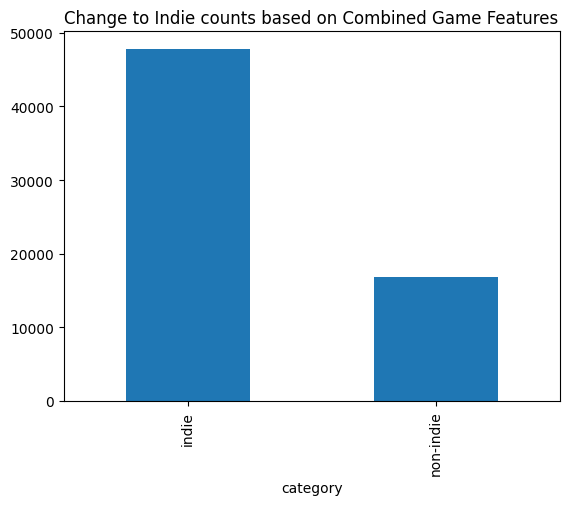

In [ ]:
# bar graph of indie or not
result['category'].value_counts().plot(kind='bar')
#titled: Change to Indie counts based on Combined Game Features:
plt.title('Change to Indie counts based on Combined Game Features')

#print counts
print("inide: ", result['category'].value_counts()[0])
print("non-indie: ", result['category'].value_counts()[1])

In [ ]:
del steamspy_data, game_data
gc.collect()
del gd, gd1, gd2, gd3, gd4, ssd, ssd1, ssd2, ssd3, ssd_copy
gc.collect()

0

In [ ]:
# see which repeated columns we want to keep
check = result[['publisher', 'publisher_game', 'name', 'name_game', 'developer', 'developer_game', 'genre', 'genre_game']]
print(check.info())
check.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64675 entries, 0 to 64674
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   publisher       64405 non-null  object
 1   publisher_game  64115 non-null  object
 2   name            64665 non-null  object
 3   name_game       64667 non-null  object
 4   developer       64488 non-null  object
 5   developer_game  64493 non-null  object
 6   genre           64447 non-null  object
 7   genre_game      64553 non-null  object
dtypes: object(8)
memory usage: 3.9+ MB
None


,publisher,publisher_game,name,name_game,developer,developer_game,genre,genre_game
0,Valve,['Valve'],Counter-Strike,Counter-Strike,Valve,['Valve'],Action,"[{'id': '1', 'description': 'Action'}]"
1,Valve,['Valve'],Team Fortress Classic,Team Fortress Classic,Valve,['Valve'],Action,"[{'id': '1', 'description': 'Action'}]"
2,Valve,['Valve'],Day of Defeat,Day of Defeat,Valve,['Valve'],Action,"[{'id': '1', 'description': 'Action'}]"
3,Valve,['Valve'],Deathmatch Classic,Deathmatch Classic,Valve,['Valve'],Action,"[{'id': '1', 'description': 'Action'}]"
4,Valve,['Valve'],Half-Life: Opposing Force,Half-Life: Opposing Force,Gearbox Software,['Gearbox Software'],Action,"[{'id': '1', 'description': 'Action'}]"


In [ ]:
del check
gc.collect()

31

In [ ]:
d1 = result[['appid', 'average_2weeks', 'average_forever', 'ccu', 'developer']] # cut developer
d2 = result[['discount', 'genre', 'initialprice', 'languages', 'median_2weeks']] # cut nothing
d3 = result[['median_forever', 'name', 'negative', 'owners', 'positive']] # cut nothing
d4 = result[['price', 'publisher', 'tags', 'userscore', 'about_the_game']] # cut userscore, publisher and about the game, userscore is vastly majority zeros
d5 = result[['achievements', 'background', 'categories', 'content_descriptors', 'detailed_description']] # cut acheievements, background, detailed desc
d6 = result[['developer_game', 'genre_game', 'header_image', 'is_free', 'linux_requirements']] # cut all but is_free
d7 = result[['mac_requirements', 'movies', 'name_game', 'package_groups', 'packages']]  # cut all
d8 = result[['pc_requirements', 'platforms', 'price_overview', 'publisher_game', 'release_date']] # cut all but release date
d9 = result[['required_age', 'screenshots', 'short_description', 'support_info', 'supported_languages', 'type', 'website']] # cut all but required age

In [ ]:
del d1, d2, d3, d4, d5, d6, d7, d8, d9
gc.collect()

0

In [ ]:
# can stay: controller support, website, platforms
# categories looks to be features, multiplayer/familysharing/anticheat
# reccomendations/achievements -> pull the number out
# cut + reason:
# dlc/demos/packages -> lack of time to sort through what the numbers mean, and if it should be a count of dlc
# platform requirements -> unsure what is wanted + theyre a mess to look at
# price overview -> we get similar information on the price, initial price, and discount columns
# score rank is pretty much empty

In [ ]:
df = result[['appid', 'name', 'genre', 'price', 'discount', 'initialprice', 'required_age', 'median_2weeks', 'median_forever', 'average_2weeks', 'average_forever', 'ccu',
              'positive', 'negative', 'languages', 'owners', 'tags', 'categories', 'is_free', 'release_date', 'controller_support', 'website', 'platforms', 'recommendations', 'achievements']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64675 entries, 0 to 64674
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   appid               64675 non-null  int64  
 1   name                64665 non-null  object 
 2   genre               64447 non-null  object 
 3   price               64674 non-null  float64
 4   discount            64674 non-null  float64
 5   initialprice        64674 non-null  float64
 6   required_age        64675 non-null  object 
 7   median_2weeks       64675 non-null  int64  
 8   median_forever      64675 non-null  int64  
 9   average_2weeks      64675 non-null  int64  
 10  average_forever     64675 non-null  int64  
 11  ccu                 64675 non-null  int64  
 12  positive            64675 non-null  int64  
 13  negative            64675 non-null  int64  
 14  languages           64653 non-null  object 
 15  owners              64675 non-null  object 
 16  tags

In [ ]:
df['languages'] = df.languages.fillna("")
df['languages'] = df.languages.str.split(',').str.len() # run the cell previous, then run this cell again if this fails
df['price'] = df.price.apply(lambda x: x/100)
df['initialprice'] = df.initialprice.apply(lambda x: x/100)
df['required_age'] = df.required_age.fillna("0")
df.loc[ df['required_age'] == '17+', 'required_age'] = '17'
df['required_age'] = df['required_age'].astype('int64')
df['recommendations'] = df.recommendations.fillna("0")
df['recommendations'] = df.recommendations.str.extract(r'(\d+[.\d]*)')
df['achievements'] = df.achievements.fillna("0")
df['achievements'] = df.achievements.str.extract(r'(\d+[.\d]*)')
df['controller_support'] = (df.controller_support.notnull()).astype('int')
df['website'] = (df.website.notnull()).astype('int')
df['is_free'] = df.is_free.fillna("0")
df['is_free'] = df.is_free.astype('int')

<ipython-input-26-899af7b57e3a>:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_free'] = df.is_free.fillna("0")


In [ ]:
# TODO
# separate platforms and make binary
# genre
# tags
# categories

In [ ]:
print(df.shape)
print(df.info())

(64675, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64675 entries, 0 to 64674
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   appid               64675 non-null  int64  
 1   name                64665 non-null  object 
 2   genre               64447 non-null  object 
 3   price               64674 non-null  float64
 4   discount            64674 non-null  float64
 5   initialprice        64674 non-null  float64
 6   required_age        64675 non-null  int64  
 7   median_2weeks       64675 non-null  int64  
 8   median_forever      64675 non-null  int64  
 9   average_2weeks      64675 non-null  int64  
 10  average_forever     64675 non-null  int64  
 11  ccu                 64675 non-null  int64  
 12  positive            64675 non-null  int64  
 13  negative            64675 non-null  int64  
 14  languages           64675 non-null  int64  
 15  owners              64675 non-null  objec

In [ ]:
#df.to_csv('/content/drive/MyDrive/Dat490/Data/combined_df_cleaned.csv', index=False)
df_cleaned = pd.read_csv('/content/drive/MyDrive/Dat490/Data/combined_df_cleaned.csv')
df_cleaned.head()

,appid,name,genre,price,discount,initialprice,required_age,median_2weeks,median_forever,average_2weeks,...,owners,tags,categories,is_free,release_date,controller_support,website,platforms,recommendations,achievements
0,10,Counter-Strike,Action,9.99,0.0,9.99,0,61,268,299,...,"10,000,000 .. 20,000,000","{'Action': 5477, 'FPS': 4902, 'Multiplayer': 3...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,"Nov 1, 2000",0,0,"{'windows': True, 'mac': True, 'linux': True}",152593,0
1,20,Team Fortress Classic,Action,4.99,0.0,4.99,0,0,20,0,...,"5,000,000 .. 10,000,000","{'Action': 764, 'FPS': 327, 'Multiplayer': 277...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,"Apr 1, 1999",0,0,"{'windows': True, 'mac': True, 'linux': True}",6250,0
2,30,Day of Defeat,Action,4.99,0.0,4.99,0,211,19,211,...,"1,000,000 .. 2,000,000","{'FPS': 799, 'World War II': 270, 'Multiplayer...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,"May 1, 2003",0,1,"{'windows': True, 'mac': True, 'linux': True}",4134,0
3,40,Deathmatch Classic,Action,4.99,0.0,4.99,0,31,16,31,...,"5,000,000 .. 10,000,000","{'Action': 635, 'FPS': 151, 'Classic': 115, 'M...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,"Jun 1, 2001",0,0,"{'windows': True, 'mac': True, 'linux': True}",2212,0
4,50,Half-Life: Opposing Force,Action,4.99,0.0,4.99,0,0,270,0,...,"2,000,000 .. 5,000,000","{'FPS': 920, 'Action': 354, 'Classic': 286, 'S...","[{'id': 2, 'description': 'Single-player'}, {'...",0,"Nov 1, 1999",0,0,"{'windows': True, 'mac': True, 'linux': True}",19968,0


In [ ]:
#converting release_date to days_released:
df_cleaned['release_date'] = pd.to_datetime(df_cleaned['release_date'], format='%b %d, %Y', errors='coerce')
# The errors='coerce' argument tells the function to replace invalid values with NaT (Not a Time)
today = pd.to_datetime('today')
df_cleaned['days_released'] = (today - df_cleaned['release_date']).dt.days

# Function to extract the upper limit (max value) from the owner range
def get_max_owners(owner_range):
    # Remove commas and split by '..'
    range_parts = owner_range.replace(',', '').split('..')
    # Take the upper limit, strip any extra spaces, and convert to an integer
    return int(range_parts[1].strip())

# Apply the function to the 'owners' column to create a new column with the max values
df_cleaned['max_owners'] = df_cleaned['owners'].apply(get_max_owners)
df_cleaned.head()
df_cleaned.drop(columns=['owners'], inplace=True)

# if owners = 20k replace with 10k:
df_cleaned['max_owners'] = df_cleaned['max_owners'].replace(20000, 10000)

In [ ]:
# all games where days_released is less than 1:
df_cleaned[df_cleaned['days_released'] < 10]
#dropping games with less than 1 days_released:
df_cleaned = df_cleaned[df_cleaned['days_released'] > 1]

In [ ]:
pd.set_option('display.max_columns', 26)

reg_df = df_cleaned.copy()
reg_df = reg_df.drop(columns=[ 'languages', 'required_age', 'categories', 'is_free', 'release_date', 'controller_support', 'website', 'platforms', 'price', 'discount', 'average_2weeks', 'average_forever', 'achievements'])
reg_df.head()

#move tags so it's 4th column:
tags = reg_df.pop('tags')
reg_df.insert(3, 'tags', tags)


#creating positive / days_released as PosPerDay:
reg_df['PosPerDay'] = reg_df['positive'] / reg_df['days_released']
reg_df['NegPerDay'] = reg_df['negative'] / reg_df['days_released']
reg_df['RecsPerDay'] = reg_df['recommendations'] / reg_df['days_released']
reg_df['MaxOwnersPerDay'] = reg_df['max_owners'] / reg_df['days_released']
reg_df.head()

print(reg_df.drop(columns=['appid', 'name', 'genre', 'tags']).nunique())
reg_df.isna().sum()

print(reg_df.drop(columns=['appid', 'name', 'genre', 'tags']).nunique())
print(reg_df.info())

#how many nulls?
reg_df.isna().sum()

print((reg_df == 0).sum())

initialprice         300
median_2weeks        363
median_forever      1663
ccu                 1160
positive            5037
negative            2516
recommendations     4511
days_released       4613
max_owners            14
PosPerDay          41722
NegPerDay          31532
RecsPerDay         14435
MaxOwnersPerDay    11712
dtype: int64
initialprice         300
median_2weeks        363
median_forever      1663
ccu                 1160
positive            5037
negative            2516
recommendations     4511
days_released       4613
max_owners            14
PosPerDay          41722
NegPerDay          31532
RecsPerDay         14435
MaxOwnersPerDay    11712
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 64369 entries, 0 to 64674
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   appid            64369 non-null  int64  
 1   name             64359 non-null  object 
 2   genre            64157 non-null

In [ ]:
df3 = df_cleaned[['appid', 'name', 'positive', 'negative']]

df_cleaned['percent_positive'] = df3.apply(lambda x: x['positive'] if (x['negative'] + x['positive']) < 1
                                    else x['positive']/(x['negative'] + x['positive']), axis=1)
df_cleaned.head()

,appid,name,genre,price,discount,initialprice,required_age,median_2weeks,median_forever,average_2weeks,average_forever,ccu,positive,...,languages,tags,categories,is_free,release_date,controller_support,website,platforms,recommendations,achievements,days_released,max_owners,percent_positive
0,10,Counter-Strike,Action,9.99,0.0,9.99,0,61,268,299,9754,15312,234532,...,8,"{'Action': 5477, 'FPS': 4902, 'Multiplayer': 3...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,2000-11-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",152593,0,8745.0,20000000,0.974346
1,20,Team Fortress Classic,Action,4.99,0.0,4.99,0,0,20,0,399,72,7283,...,9,"{'Action': 764, 'FPS': 327, 'Multiplayer': 277...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,1999-04-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",6250,0,9325.0,10000000,0.869093
2,30,Day of Defeat,Action,4.99,0.0,4.99,0,211,19,211,9183,95,6225,...,5,"{'FPS': 799, 'World War II': 270, 'Multiplayer...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,2003-05-01,0,1,"{'windows': True, 'mac': True, 'linux': True}",4134,0,7834.0,2000000,0.902174
3,40,Deathmatch Classic,Action,4.99,0.0,4.99,0,31,16,31,582,2,2536,...,9,"{'Action': 635, 'FPS': 151, 'Classic': 115, 'M...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,2001-06-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",2212,0,8533.0,10000000,0.828758
4,50,Half-Life: Opposing Force,Action,4.99,0.0,4.99,0,0,270,0,846,128,22069,...,4,"{'FPS': 920, 'Action': 354, 'Classic': 286, 'S...","[{'id': 2, 'description': 'Single-player'}, {'...",0,1999-11-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",19968,0,9111.0,5000000,0.952071


Text(0.5, 1.0, 'Chart of the Percentage of Positive Reviews for Games')

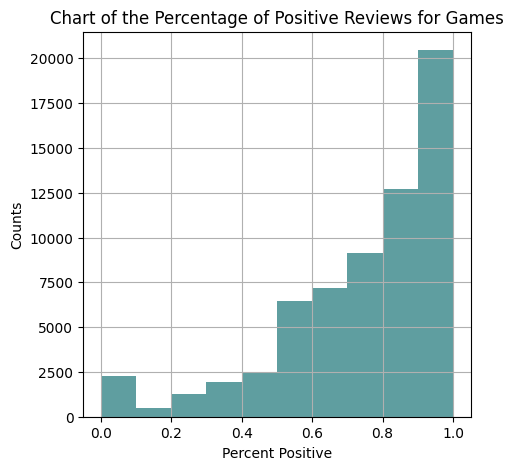

In [ ]:
fig, ax1 = plt.subplots(figsize = (5, 5))

df_cleaned['percent_positive'].hist(color = 'cadetblue')
ax1.set_xlabel('Percent Positive', fontsize = 10)
ax1.set_ylabel('Counts', fontsize = 10)
ax1.set_title('Chart of the Percentage of Positive Reviews for Games')

<Axes: >

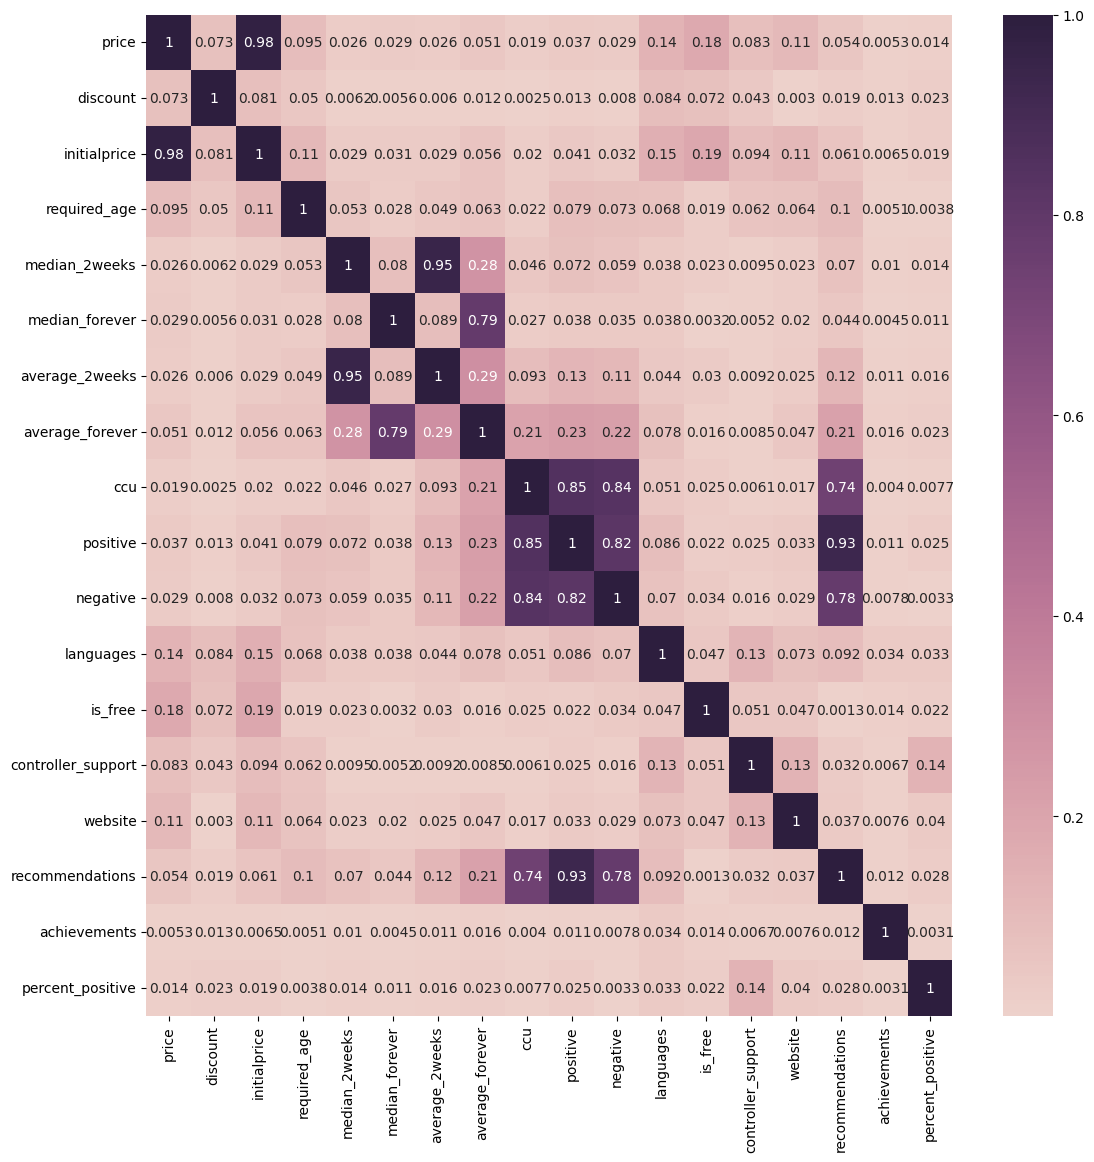

In [ ]:
df1 = df_cleaned[['price', 'discount', 'initialprice', 'required_age', 'median_2weeks', 'median_forever', 'average_2weeks', 'average_forever', 'ccu',
              'positive', 'negative', 'languages', 'is_free', 'controller_support', 'website', 'recommendations', 'achievements', 'percent_positive']]
fig, ax1 = plt.subplots(figsize=(13, 13))
sns.heatmap(np.abs(df1.corr()), annot=True, ax=ax1, cmap = sns.cubehelix_palette(as_cmap = True))

Looking over the heat map, all the high correlations make sense and seem like things we expected to see have correlations

In [ ]:
df2 = df_cleaned['genre']
df2 = df2.fillna("none")
tot_genres = []

for i in range(0, len(df2)):
  genres = df2.iloc[i].split(', ')

  for j in range(0, len(genres)):
    tot_genres.append(genres[j])

genre_count = Counter(tot_genres)
genre_count

# converting genre_count to df:
genre_df = pd.DataFrame.from_dict(genre_count, orient = 'index').reset_index()
genre_df = genre_df.rename(columns = {'index':'genre', 0:'count'})

# saving df as csv:
genre_df.to_csv('/content/drive/MyDrive/Dat490/Data/genre_count.csv', index = False)


,appid,name,genre,price,discount,initialprice,required_age,median_2weeks,median_forever,average_2weeks,average_forever,ccu,positive,...,languages,tags,categories,is_free,release_date,controller_support,website,platforms,recommendations,achievements,days_released,max_owners,percent_positive
0,10,Counter-Strike,Action,9.99,0.0,9.99,0,61,268,299,9754,15312,234532,...,8,"{'Action': 5477, 'FPS': 4902, 'Multiplayer': 3...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,2000-11-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",152593,0,8745.0,20000000,0.974346
1,20,Team Fortress Classic,Action,4.99,0.0,4.99,0,0,20,0,399,72,7283,...,9,"{'Action': 764, 'FPS': 327, 'Multiplayer': 277...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,1999-04-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",6250,0,9325.0,10000000,0.869093
2,30,Day of Defeat,Action,4.99,0.0,4.99,0,211,19,211,9183,95,6225,...,5,"{'FPS': 799, 'World War II': 270, 'Multiplayer...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,2003-05-01,0,1,"{'windows': True, 'mac': True, 'linux': True}",4134,0,7834.0,2000000,0.902174
3,40,Deathmatch Classic,Action,4.99,0.0,4.99,0,31,16,31,582,2,2536,...,9,"{'Action': 635, 'FPS': 151, 'Classic': 115, 'M...","[{'id': 1, 'description': 'Multi-player'}, {'i...",0,2001-06-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",2212,0,8533.0,10000000,0.828758
4,50,Half-Life: Opposing Force,Action,4.99,0.0,4.99,0,0,270,0,846,128,22069,...,4,"{'FPS': 920, 'Action': 354, 'Classic': 286, 'S...","[{'id': 2, 'description': 'Single-player'}, {'...",0,1999-11-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",19968,0,9111.0,5000000,0.952071


In [ ]:
pretty_df = df_cleaned.copy()
pretty_df = pretty_df[['appid', 'name', 'genre', 'price', 'discount', 'initialprice', 'required_age', 'median_2weeks', 'median_forever', 'average_2weeks', 'average_forever', 'ccu',
                       'positive', 'negative', 'languages', 'tags', 'is_free', 'release_date', 'controller_support', 'website', 'platforms', 'recommendations', 'achievements', 'days_released', 'max_owners', 'percent_positive']]
pretty_df.head()


,appid,name,genre,price,discount,initialprice,required_age,median_2weeks,median_forever,average_2weeks,average_forever,ccu,positive,negative,languages,tags,is_free,release_date,controller_support,website,platforms,recommendations,achievements,days_released,max_owners,percent_positive
0,10,Counter-Strike,Action,9.99,0.0,9.99,0,61,268,299,9754,15312,234532,6175,8,"{'Action': 5477, 'FPS': 4902, 'Multiplayer': 3...",0,2000-11-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",152593,0,8745.0,20000000,0.974346
1,20,Team Fortress Classic,Action,4.99,0.0,4.99,0,0,20,0,399,72,7283,1097,9,"{'Action': 764, 'FPS': 327, 'Multiplayer': 277...",0,1999-04-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",6250,0,9325.0,10000000,0.869093
2,30,Day of Defeat,Action,4.99,0.0,4.99,0,211,19,211,9183,95,6225,675,5,"{'FPS': 799, 'World War II': 270, 'Multiplayer...",0,2003-05-01,0,1,"{'windows': True, 'mac': True, 'linux': True}",4134,0,7834.0,2000000,0.902174
3,40,Deathmatch Classic,Action,4.99,0.0,4.99,0,31,16,31,582,2,2536,524,9,"{'Action': 635, 'FPS': 151, 'Classic': 115, 'M...",0,2001-06-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",2212,0,8533.0,10000000,0.828758
4,50,Half-Life: Opposing Force,Action,4.99,0.0,4.99,0,0,270,0,846,128,22069,1111,4,"{'FPS': 920, 'Action': 354, 'Classic': 286, 'S...",0,1999-11-01,0,0,"{'windows': True, 'mac': True, 'linux': True}",19968,0,9111.0,5000000,0.952071


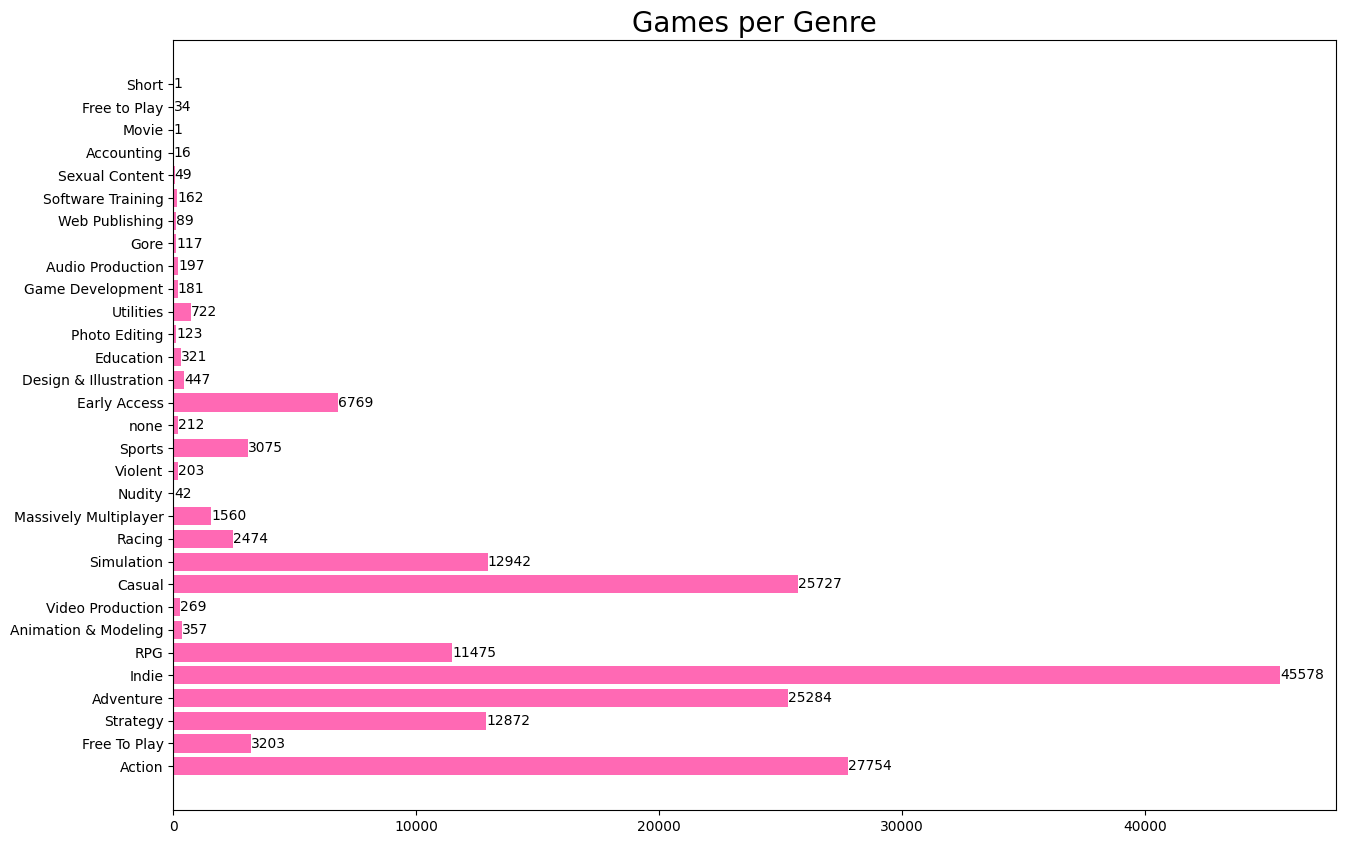

In [ ]:
fig, ax = plt.subplots(figsize =(15, 10))

plt.barh(range(len(genre_count)), list(genre_count.values()), color = "hotpink")
plt.yticks(range(len(genre_count)), list(genre_count.keys()))
ax.set_title('Games per Genre', fontsize = 20)
ax.bar_label(ax.containers[-1])
plt.show()

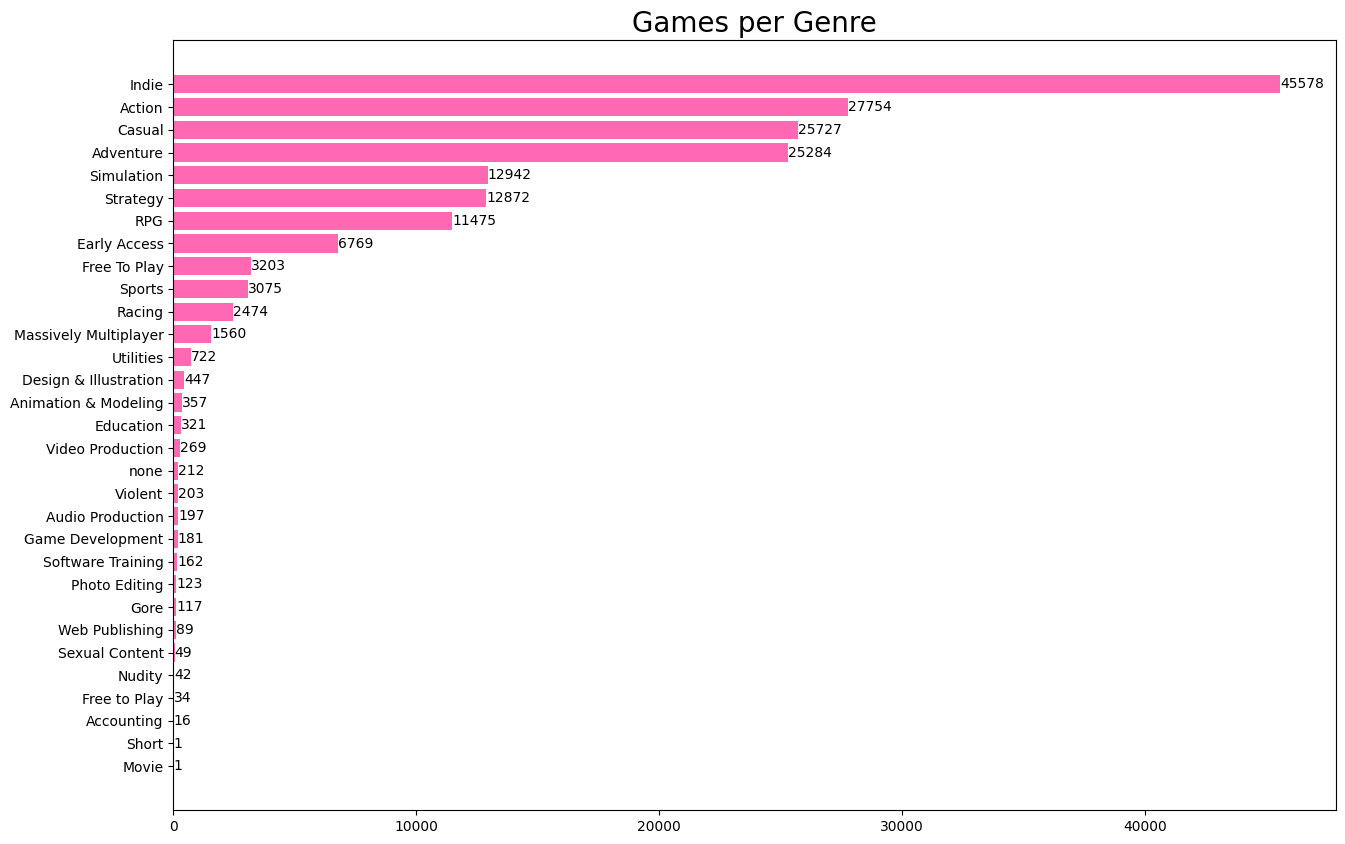

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))

# Sort the genre_count dictionary by values (counts)
sorted_genre_count = dict(sorted(genre_count.items(), key=lambda item: item[1]))

# Plot the sorted data
plt.barh(range(len(sorted_genre_count)), list(sorted_genre_count.values()), color="hotpink")
plt.yticks(range(len(sorted_genre_count)), list(sorted_genre_count.keys()))
ax.set_title('Games per Genre', fontsize=20)
ax.bar_label(ax.containers[-1])
plt.show()

In [ ]:
df4 = df_cleaned['tags']
df4 = df4.fillna("none")
tot_tags = []

for i in range(0, len(df4)):
  res = ast.literal_eval(str(df4.iloc[i])) # returns lists if nans
  if isinstance(res, dict): # ignores nans
    tag_keys = res.keys()
    tags = list(tag_keys)

    for j in range(0, len(tags)):
      tot_tags.append(tags[j])


['Comedy',
 'Horror',
 'Cute',
 'Psychological Horror',
 'Adventure',
 'Life Sim',
 'First-Person',
 'Exploration',
 'Anime',
 'Atmospheric',
 'Walking Simulator',
 'Relaxing',
 'Casual',
 'Action-Adventure',
 '3D',
 'Simulation',
 'Modern',
 'Story Rich',
 'Indie',
 'Singleplayer']

In [ ]:
tag_count = Counter(tot_tags)

print(len(tag_count))

tag_df = pd.DataFrame.from_dict(tag_count, orient='index').reset_index()
tag_df = tag_df.rename(columns={'index':'tag', 0:'count'})
tag_df = tag_df.sort_values('count')
tags_split = np.array_split(tag_df, 10)
tags_split0 = tags_split[0]
tags_split1 = tags_split[1]
tags_split2 = tags_split[2]
tags_split3 = tags_split[3]
tags_split4 = tags_split[4]
tags_split5 = tags_split[5]
tags_split6 = tags_split[6]
tags_split7 = tags_split[7]
tags_split8 = tags_split[8]
tags_split9 = tags_split[9]

# save tag count:
tag_df.to_csv('/content/drive/MyDrive/Dat490/Data/tag_count.csv', index=False)

450


/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
genre_df = pd.DataFrame.from_dict(genre_count, orient = 'index').reset_index()
genre_df = genre_df.rename(columns = {'index':'genre', 0:'count'})
genre_df = genre_df.sort_values('count')

genre_df.head()
#genre_df.loc[32] = ['Free To Play', 3237]

,genre,count
30,Short,1
28,Movie,1
27,Accounting,16
29,Free to Play,34
12,Nudity,42


In [ ]:
genre_df = genre_df.sort_values('count')
genre_df = genre_df.drop([1, 29])
genre_df

,genre,count
30,Short,1
28,Movie,1
27,Accounting,16
12,Nudity,42
26,Sexual Content,49
24,Web Publishing,89
23,Gore,117
19,Photo Editing,123
25,Software Training,162
21,Game Development,181


<ipython-input-48-0c99f487e733>:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  reg_df.hist(ax = ax1, bins = 25, color = 'indigo')


array([[<Axes: title={'center': 'appid'}>,
        <Axes: title={'center': 'initialprice'}>,
        <Axes: title={'center': 'median_2weeks'}>,
        <Axes: title={'center': 'median_forever'}>],
       [<Axes: title={'center': 'ccu'}>,
        <Axes: title={'center': 'positive'}>,
        <Axes: title={'center': 'negative'}>,
        <Axes: title={'center': 'recommendations'}>],
       [<Axes: title={'center': 'days_released'}>,
        <Axes: title={'center': 'max_owners'}>,
        <Axes: title={'center': 'PosPerDay'}>,
        <Axes: title={'center': 'NegPerDay'}>],
       [<Axes: title={'center': 'RecsPerDay'}>,
        <Axes: title={'center': 'MaxOwnersPerDay'}>, <Axes: >, <Axes: >]],
      dtype=object)

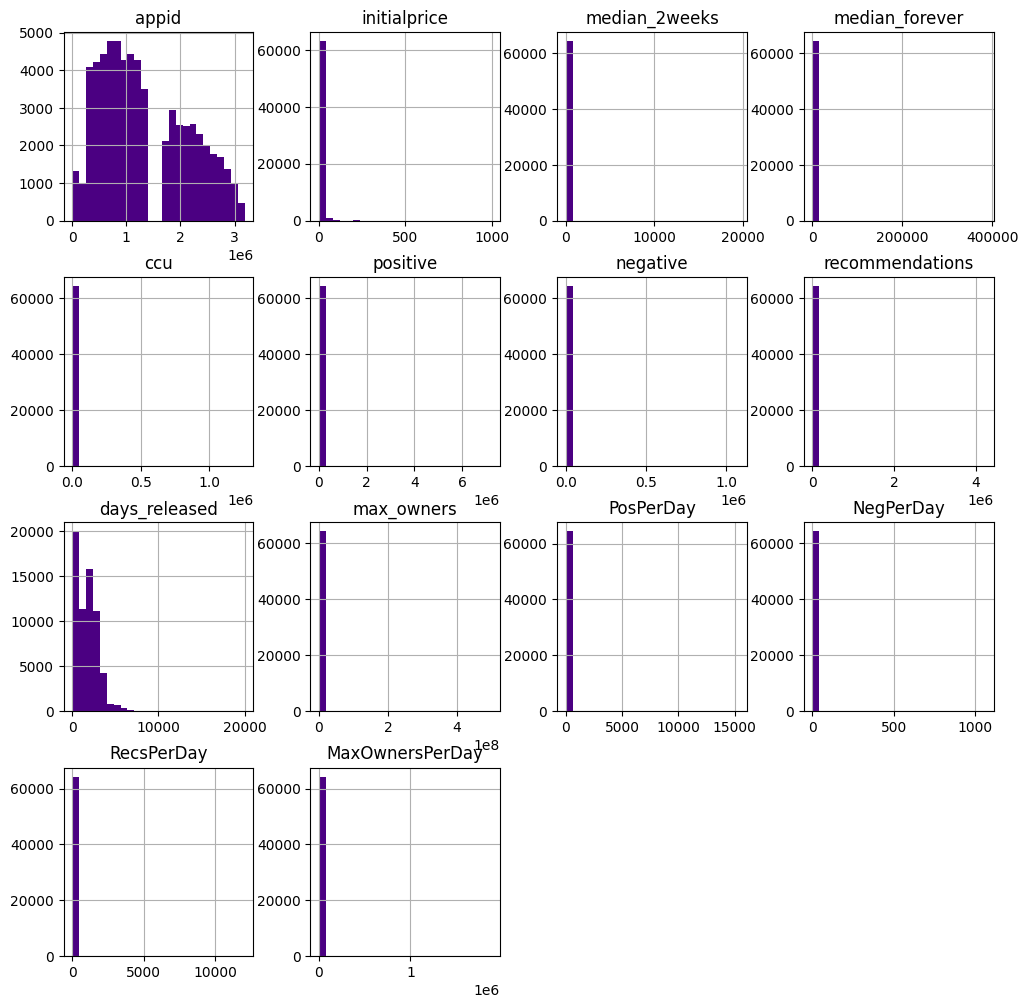

In [ ]:
fig, ax1 = plt.subplots(figsize = (12, 12))

reg_df.hist(ax = ax1, bins = 25, color = 'indigo')

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Drop 'appid', 'name', 'genre', 'tags' as they shouldn't be scaled
features_to_scale = reg_df.drop(columns=['appid', 'name', 'genre', 'tags'])

# Log transform all relevant columns (including 'max_owners')
columns_to_log_transform = [
    'MaxOwnersPerDay', 'initialprice', 'median_2weeks', 'median_forever',
    'ccu', 'PosPerDay', 'NegPerDay', 'RecsPerDay'
]

# Apply log1p transformation to avoid log(0)
for col in columns_to_log_transform:
    features_to_scale[f'log_{col}'] = np.log1p(features_to_scale[col])

# Remove the original columns that were log-transformed
features_to_scale = features_to_scale.drop(columns=columns_to_log_transform)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the remaining features
scaled_features = scaler.fit_transform(features_to_scale)

# Convert the scaled features back into a DataFrame
df_scaled_feat = pd.DataFrame(scaled_features, columns=features_to_scale.columns)

# Concatenate 'appid', 'name', 'genre', and 'tags' with the scaled features
success_df_final = pd.concat([reg_df[['appid', 'name', 'genre', 'tags']], df_scaled_feat], axis=1)

# Output the final DataFrame
print(success_df_final.info())
print(success_df_final.head())

<class 'pandas.core.frame.DataFrame'>
Index: 64675 entries, 0 to 51432
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   appid                64369 non-null  float64
 1   name                 64359 non-null  object 
 2   genre                64157 non-null  object 
 3   tags                 64369 non-null  object 
 4   positive             64369 non-null  float64
 5   negative             64369 non-null  float64
 6   recommendations      64369 non-null  float64
 7   days_released        64369 non-null  float64
 8   max_owners           64369 non-null  float64
 9   log_MaxOwnersPerDay  64369 non-null  float64
 10  log_initialprice     64369 non-null  float64
 11  log_median_2weeks    64369 non-null  float64
 12  log_median_forever   64369 non-null  float64
 13  log_ccu              64369 non-null  float64
 14  log_PosPerDay        64369 non-null  float64
 15  log_NegPerDay        64369 non-null  floa

<ipython-input-50-f73b194a2b17>:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  success_df_final.hist(ax = ax1, bins = 25, color = 'slateblue')


array([[<Axes: title={'center': 'appid'}>,
        <Axes: title={'center': 'positive'}>,
        <Axes: title={'center': 'negative'}>,
        <Axes: title={'center': 'recommendations'}>],
       [<Axes: title={'center': 'days_released'}>,
        <Axes: title={'center': 'max_owners'}>,
        <Axes: title={'center': 'log_MaxOwnersPerDay'}>,
        <Axes: title={'center': 'log_initialprice'}>],
       [<Axes: title={'center': 'log_median_2weeks'}>,
        <Axes: title={'center': 'log_median_forever'}>,
        <Axes: title={'center': 'log_ccu'}>,
        <Axes: title={'center': 'log_PosPerDay'}>],
       [<Axes: title={'center': 'log_NegPerDay'}>,
        <Axes: title={'center': 'log_RecsPerDay'}>, <Axes: >, <Axes: >]],
      dtype=object)

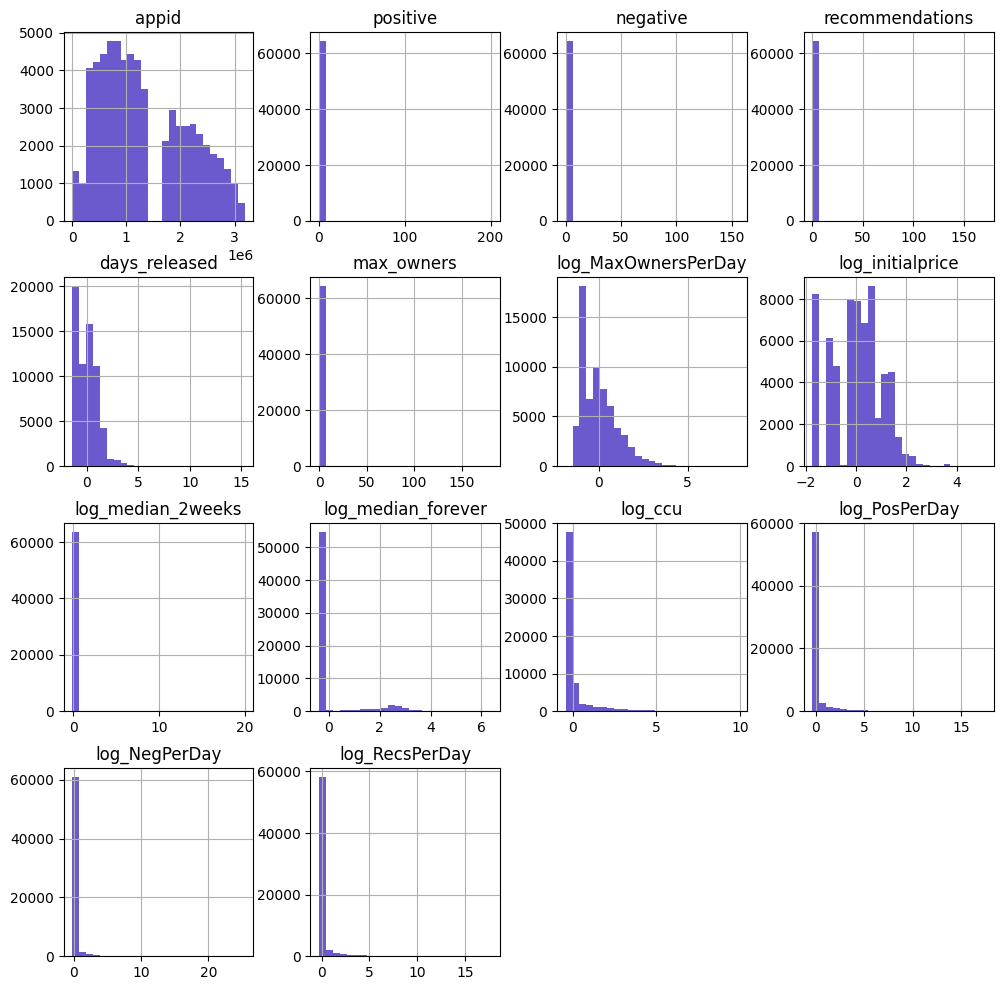

In [ ]:
fig, ax1 = plt.subplots(figsize = (12, 12))

success_df_final.hist(ax = ax1, bins = 25, color = 'slateblue')

In [ ]:
multiple = 0
single = 0
nans = 0

for i in range(0, len(success_df_final)):

  num = success_df_final.loc[i, 'genre']

  if type(num) == float:
    nans = nans + 1
  elif num.find(',') != -1:
    multiple = multiple + 1
  else:
    single = single + 1


Text(0, 0.5, 'Counts')

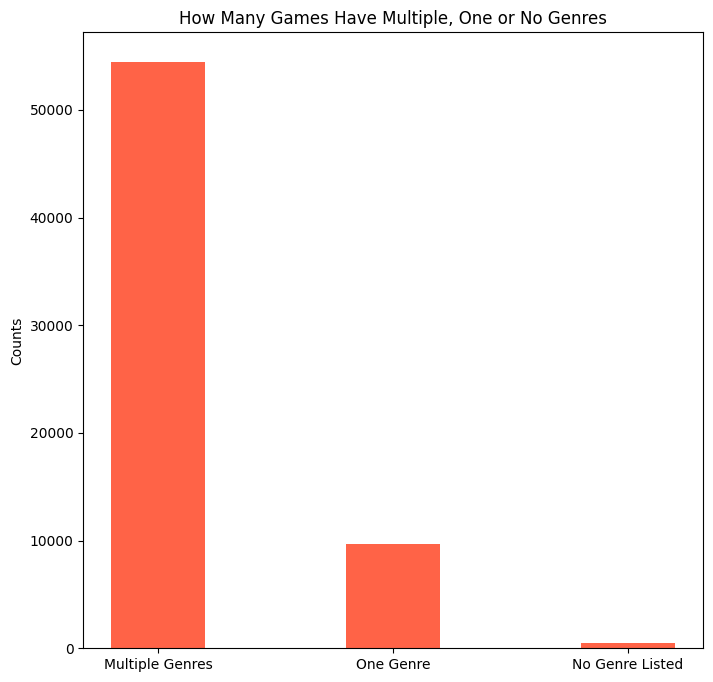

In [ ]:
counts = [multiple, single, nans]

values = ["Multiple Genres", 'One Genre', 'No Genre Listed']

fig, ax1 = plt.subplots(figsize = (8, 8))

ax1.bar(values, counts, width = 0.4, color = 'tomato')
plt.title('How Many Games Have Multiple, One or No Genres')
plt.ylabel('Counts')

In [ ]:
indie = 0
non = 0

for i in range(0, len(success_df_final)):

  num = success_df_final.loc[i, 'genre']

  if type(num) == float:
    num = num
  elif num.find('Indie') != -1:
    indie = indie + 1
  else:
    non = non + 1

print(indie)
print(non)

45578
18579


Text(0, 0.5, 'Count')

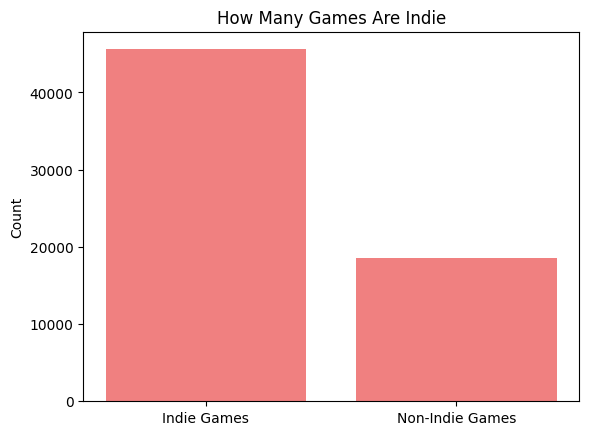

In [ ]:
counts = [indie, non]

values = ['Indie Games', 'Non-Indie Games']

plt.bar(values, counts, color = 'lightcoral')

plt.title('How Many Games Are Indie')

plt.ylabel('Count')

Text(0.5, 1.0, 'Correlation Between log_negperday and log_ccu')

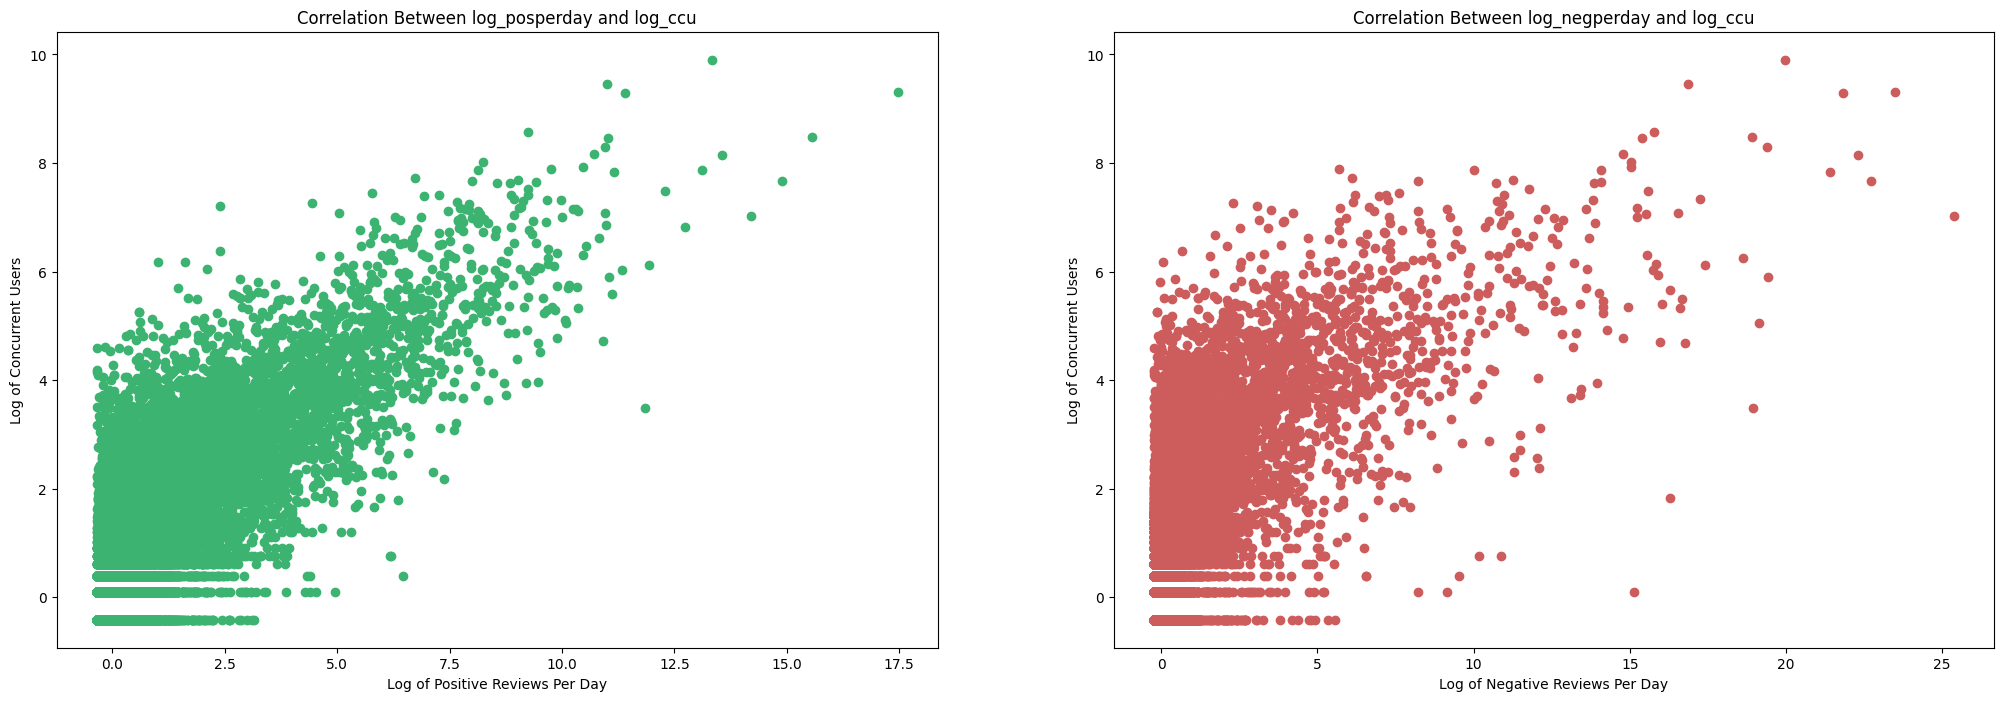

In [ ]:
fig, ax = plt.subplots(1, 2, figsize =(25, 8))

ax[0].scatter(success_df_final['log_PosPerDay'], success_df_final['log_ccu'], color = 'mediumseagreen')
ax[0].set_xlabel('Log of Positive Reviews Per Day')
ax[0].set_ylabel('Log of Concurrent Users')
ax[0].set_title('Correlation Between log_posperday and log_ccu')

ax[1].scatter(success_df_final['log_NegPerDay'], success_df_final['log_ccu'], color = 'indianred')
ax[1].set_xlabel('Log of Negative Reviews Per Day')
ax[1].set_ylabel('Log of Concurrent Users')
ax[1].set_title('Correlation Between log_negperday and log_ccu')

In [ ]:
# Weights for indie and non-indie games, refocused after removing ccu
indie_weights = {
    'current_engagement': 0.15,  # Focuses on player recommendations
    'overall_feedback': 0.075,    # Measures the game's total review sentiment
    'current_feedback': 0.075,    # Measures current player sentiment
    'current_commercial': 0.20,  # Focuses on recent sales/ownership growth
    'overall_commercial': 0.50   # Emphasizes total lifetime sales as a key success metric
}
non_indie_weights = {
    'current_engagement': 0.15,  # Focuses on player recommendations
    'overall_feedback': 0.075,    # Measures the game's total review sentiment
    'current_feedback': 0.075,    # Measures current player sentiment
    'current_commercial': 0.20,  # Focuses on recent sales/ownership growth
    'overall_commercial': 0.50   # Emphasizes total lifetime sales as a key success metric
}


def sanity_check(weights):
    # Extract individual weights for engagement, feedback, and commercial success
    current_engagement = weights['current_engagement']
    current_feedback = weights['current_feedback']
    overall_feedback = weights['overall_feedback']
    current_commercial = weights['current_commercial']
    overall_commercial = weights['overall_commercial']

    # Calculate total weights for each main category
    total_engagement = current_engagement
    total_feedback = current_feedback + overall_feedback
    total_commercial = current_commercial + overall_commercial

    # Calculate the sum of all weights
    total_weight = total_engagement + total_feedback + total_commercial

    # Calculate percentage contributions
    total_engagement_pct = (total_engagement / total_weight) * 100
    total_feedback_pct = (total_feedback / total_weight) * 100
    total_commercial_pct = (total_commercial / total_weight) * 100

    # Breakdown percentages for detailed view
    current_engagement_pct = (current_engagement / total_weight) * 100
    current_feedback_pct = (current_feedback / total_weight) * 100
    overall_feedback_pct = (overall_feedback / total_weight) * 100
    current_commercial_pct = (current_commercial / total_weight) * 100
    overall_commercial_pct = (overall_commercial / total_weight) * 100

    # Output results, formatted to clearly match the success formula components
    print(f"Success Metric Breakdown:")
    print(f"  Total Engagement: {total_engagement_pct:.2f}% (Recommendations/Day: {current_engagement_pct:.2f}%)")
    print(f"  Total Feedback: {total_feedback_pct:.2f}% (Current Positive Reviews/Day: {current_feedback_pct:.2f}%, Overall Review Sentiment: {overall_feedback_pct:.2f}%)")
    print(f"  Total Commercial Success: {total_commercial_pct:.2f}% (Current Sales/Owners/Day: {current_commercial_pct:.2f}%, Total Lifetime Sales: {overall_commercial_pct:.2f}%)")



print("Indie Game Weights:")
sanity_check(indie_weights)

print("\nNon-Indie Game Weights:")
sanity_check(non_indie_weights)


Indie Game Weights:
Success Metric Breakdown:
  Total Engagement: 15.00% (Recommendations/Day: 15.00%)
  Total Feedback: 15.00% (Current Positive Reviews/Day: 7.50%, Overall Review Sentiment: 7.50%)
  Total Commercial Success: 70.00% (Current Sales/Owners/Day: 20.00%, Total Lifetime Sales: 50.00%)

Non-Indie Game Weights:
Success Metric Breakdown:
  Total Engagement: 15.00% (Recommendations/Day: 15.00%)
  Total Feedback: 15.00% (Current Positive Reviews/Day: 7.50%, Overall Review Sentiment: 7.50%)
  Total Commercial Success: 70.00% (Current Sales/Owners/Day: 20.00%, Total Lifetime Sales: 50.00%)


In [ ]:
def success(df, start, end, indie_weights, non_indie_weights):
    success = []
    df = df.fillna(0)  # Set all NaN values to zero

    for i in range(start, end):
        # Determine if the game is indie based on 'genre' or 'tags'
        if "Indie" in str(df.iloc[i]['genre']) or "Indie" in str(df.iloc[i]['tags']):
            weights = indie_weights
        else:
            weights = non_indie_weights

        # Calculate feedback score using the log-transformed columns
        total_reviews = df.iloc[i]['log_PosPerDay'] + df.iloc[i]['log_NegPerDay']
        feedback_score = (
            0 if total_reviews == 0 else
            max(0, (df.iloc[i]['log_PosPerDay'] - 1 / (total_reviews + 1)) +
                (1 - (df.iloc[i]['log_NegPerDay'] - 1 / (total_reviews + 1))))
        )

        # Calculate success metric
        metric = (
            weights['current_engagement'] * df.iloc[i]['log_RecsPerDay'] +  # Current engagement
            weights['current_feedback'] * df.iloc[i]['log_PosPerDay'] +     # Current positive reviews/day
            weights['overall_feedback'] * feedback_score +                  # Overall review sentiment
            weights['current_commercial'] * df.iloc[i]['log_MaxOwnersPerDay'] +  # Current sales/owners/day
            weights['overall_commercial'] * df.iloc[i]['log_MaxOwnersPerDay']    # Total lifetime sales
        )

        success.append(metric)

    return success

In [ ]:
#df_sample = success_df_final.sample(1000, random_state=0)
#success_scores = success(df_sample, 0, len(df_sample), indie_weights, non_indie_weights)

#success_scores = success(success_df_final, 0, len(success_df_final), indie_weights, non_indie_weights)
#joining success_scores with success_df_final

#df_sample['success'] = success_scores
#success_df_final['success'] = success_scores
#success_df_final.sample(10)

In [ ]:
success_df_final.sample(10)

,appid,name,genre,tags,positive,negative,recommendations,days_released,max_owners,log_MaxOwnersPerDay,log_initialprice,log_median_2weeks,log_median_forever,log_ccu,log_PosPerDay,log_NegPerDay,log_RecsPerDay
18074,712000.0,Elder Chaos,"Indie, Strategy","{'Indie': 32, 'Strategy': 31, 'Lovecraftian': ...",-0.034291,-0.025953,-0.041753,0.621477,-0.034129,0.443357,1.020192,-0.093007,2.415426,0.390297,-0.028540,-0.092422,-0.081252
13772,592480.0,Knights And Bikes,"Action, Adventure, Indie","{'Online Co-Op': 242, 'Local Co-Op': 237, 'Adv...",-0.045864,-0.034667,-0.052897,0.910271,-0.052273,-0.105692,-0.645967,-0.093007,-0.392624,-0.416928,-0.319161,-0.187808,-0.287022
25267,906310.0,Rapid Racing,Indie,{'Indie': 31},-0.046560,-0.040330,-0.052897,0.453223,-0.052273,0.037929,-1.734361,-0.093007,-0.392624,-0.416928,-0.333850,-0.238661,-0.287022
32343,1112330.0,NORR part I: Ace Shot,"Action, Indie, Massively Multiplayer","{'Action': 418, 'Indie': 412, 'Violent': 409, ...",-0.046643,-0.040185,-0.052897,0.172799,-0.066787,-0.870969,-0.645967,-0.093007,-0.392624,-0.416928,-0.335158,-0.236439,-0.287022
53348,2256160.0,Survive Now,"Action, Casual, Indie, RPG, Free To Play, Earl...","{'Action': 195, 'RPG': 189, 'Action RPG': 165,...",-0.040189,-0.033940,-0.041834,-0.943871,-0.066787,-0.118025,0.330777,-0.093007,-0.392624,0.092374,0.309264,0.040546,0.469407
5548,357890.0,Vortex Attack: ボルテックスアタック,"Action, Casual, Indie","{""Shoot 'Em Up"": 172, 'Bullet Hell': 164, 'Cas...",0.166992,-0.002572,0.241867,1.330487,0.111018,1.336223,-0.359261,-0.093007,2.345969,1.820088,1.885797,0.040925,1.960507
47606,1961760.0,My Girlfriend’s Special Place,Adventure,"{'Visual Novel': 49, 'Anime': 42, 'Adventure':...",-0.046782,-0.040330,-0.052897,-0.695257,-0.066787,-0.389619,-0.645967,-0.093007,-0.392624,-0.416928,-0.336513,-0.236052,-0.287022
54595,2322420.0,Stack Island - Survival card game,"Adventure, Indie, Simulation, Strategy, Early ...","{'Simulation': 57, 'Card Game': 49, 'Survival'...",-0.046643,-0.039895,-0.052897,-1.271171,-0.066787,0.663412,1.290566,-0.093007,-0.392624,0.092374,-0.260783,-0.157665,-0.287022
10161,494470.0,My Butler,Adventure,"{'Adventure': 24, 'Otome': 15, 'Visual Novel':...",-0.046476,-0.040040,-0.052897,0.863394,-0.066787,-1.073498,-1.734361,-0.093007,-0.392624,-0.416928,-0.333452,-0.236261,-0.287022
45122,1851630.0,Man of Sterling Quality,"Indie, Early Access","{'Psychological Horror': 43, 'Casual': 37, 'Vi...",-0.045002,-0.040185,-0.052897,-0.593970,-0.066787,-0.472439,0.044487,-0.093007,-0.392624,-0.416928,-0.221325,-0.232846,-0.287022


In [ ]:
def identify_successful_games(df, indie_required_top_count=2, non_indie_required_top_count=3, indie_top_pct=0.50, non_indie_top_pct=0.75):
    # Calculate feedback ratio
    df['feedback_ratio'] = df['positive'] / (df['positive'] + df['negative'])
    avg_feedback_ratio = df['feedback_ratio'].mean()

    # Determine indie status for each game
    is_indie = df['genre'].str.contains('Indie') | df['tags'].str.contains('Indie')

    # Calculate thresholds for indie and non-indie games
    indie_thresholds = {
        'max_owners': df[is_indie]['max_owners'].quantile(indie_top_pct),
        'log_RecsPerDay': df[is_indie]['log_RecsPerDay'].quantile(indie_top_pct),
        'log_MaxOwnersPerDay': df[is_indie]['log_MaxOwnersPerDay'].quantile(indie_top_pct),
        'log_PosPerDay': df[is_indie]['log_PosPerDay'].quantile(indie_top_pct)
    }
    non_indie_thresholds = {
        'max_owners': df[~is_indie]['max_owners'].quantile(non_indie_top_pct),
        'log_RecsPerDay': df[~is_indie]['log_RecsPerDay'].quantile(non_indie_top_pct),
        'log_MaxOwnersPerDay': df[~is_indie]['log_MaxOwnersPerDay'].quantile(non_indie_top_pct),
        'log_PosPerDay': df[~is_indie]['log_PosPerDay'].quantile(non_indie_top_pct)
    }

    # Create conditions using vectorized operations
    df['meets_max_owners'] = np.where(
        is_indie,
        df['max_owners'] >= indie_thresholds['max_owners'],
        df['max_owners'] >= non_indie_thresholds['max_owners']
    ).astype(int)
    df['meets_recs_per_day'] = np.where(
        is_indie,
        df['log_RecsPerDay'] >= indie_thresholds['log_RecsPerDay'],
        df['log_RecsPerDay'] >= non_indie_thresholds['log_RecsPerDay']
    ).astype(int)
    df['meets_owners_growth'] = np.where(
        is_indie,
        df['log_MaxOwnersPerDay'] >= indie_thresholds['log_MaxOwnersPerDay'],
        df['log_MaxOwnersPerDay'] >= non_indie_thresholds['log_MaxOwnersPerDay']
    ).astype(int)
    df['meets_pos_per_day'] = np.where(
        is_indie,
        df['log_PosPerDay'] >= indie_thresholds['log_PosPerDay'],
        df['log_PosPerDay'] >= non_indie_thresholds['log_PosPerDay']
    ).astype(int)
    df['meets_feedback'] = (df['feedback_ratio'] > avg_feedback_ratio).astype(int)

    # Count the number of conditions each game meets
    condition_columns = ['meets_max_owners', 'meets_recs_per_day', 'meets_owners_growth', 'meets_pos_per_day', 'meets_feedback']
    df['conditions_met_count'] = df[condition_columns].sum(axis=1)

    # Reminder of how many columns are considered
    num_columns = len(condition_columns)
    print(f"Number of columns being considered for success: {num_columns}")

    # Determine success based on the required number of conditions for indie and non-indie games
    df['success'] = np.where(
        (is_indie & (df['conditions_met_count'] >= indie_required_top_count)) |
        (~is_indie & (df['conditions_met_count'] >= non_indie_required_top_count)),
        1, 0
    )

    return df

# Apply the function to the DataFrame
cc = 2
per = .95
success_df_final = identify_successful_games(success_df_final, indie_required_top_count=cc, non_indie_required_top_count=cc, indie_top_pct=per, non_indie_top_pct=0.85)

# Show the distribution of identified successful games
success_count = success_df_final['success'].sum()
total_games = len(success_df_final)
indie_success_count = success_df_final[(success_df_final['success'] == 1) & (success_df_final['genre'].str.contains('Indie'))].shape[0]
non_indie_success_count = success_count - indie_success_count

print(f"Total games: {total_games}, Successful games: {success_count}")
print(f"Indie games marked successful: {indie_success_count}")
print(f"Non-indie games marked successful: {non_indie_success_count}")

Number of columns being considered for success: 5
Total games: 64675, Successful games: 6195
Indie games marked successful: 2882
Non-indie games marked successful: 3313


In [ ]:
success_df_final.shape


(64675, 25)

In [ ]:
# success sample where success = 1:
success_df_final_1 = success_df_final[success_df_final['success'] == 1]
success_df_final_1.sample(10)

,appid,name,genre,tags,positive,negative,recommendations,days_released,max_owners,log_MaxOwnersPerDay,log_initialprice,log_median_2weeks,log_median_forever,log_ccu,log_PosPerDay,log_NegPerDay,log_RecsPerDay,feedback_ratio,meets_max_owners,meets_recs_per_day,meets_owners_growth,meets_pos_per_day,meets_feedback,conditions_met_count,success
24610,886070.0,Jewel Match Solitaire,"Casual, Indie","{'Solitaire': 120, 'Casual': 109, 'Building': ...",12.193107,3.730403,16.059671,-0.290945,18.072985,5.125365,1.290566,14.271468,3.473146,7.106904,10.358849,10.826657,10.665562,0.765730,1,1,1,1,0,4,1
26293,936620.0,Petrolhead,"Action, Adventure, Indie, Racing, RPG, Simulat...","{'Simulation': 32, 'Adventure': 31, 'Indie': 3...",0.032590,-0.028132,0.060608,0.178659,-0.034129,0.608687,-0.137021,-0.093007,2.922616,0.899599,1.347811,-0.080026,1.451654,7.309325,0,1,0,0,1,2,1
5892,366240.0,GAROU: MARK OF THE WOLVES,Action,"{'Action': 40, '2D Fighter': 37, 'Arcade': 31,...",-0.035626,-0.015207,-0.036242,1.461910,0.111018,1.304205,-1.050549,-0.093007,2.357714,0.092374,-0.137799,-0.058902,-0.069875,0.700851,1,0,1,0,0,2,1
53682,2274110.0,The Elephant Collection,"Action, Adventure","{'Adventure': 91, 'Arcade': 56, '2D Platformer...",0.310630,0.325198,0.538981,-1.007490,0.292452,3.122119,1.955644,-0.093007,-0.392624,4.878629,5.758556,6.426457,6.306110,0.488545,1,1,1,1,0,4,1
4445,329630.0,Command HQ,Strategy,"{'Strategy': 27, 'Retro': 10, 'Classic': 8, ""1...",-0.037518,0.004253,-0.030731,1.540596,0.111018,1.285732,-1.050549,-0.093007,2.564203,-0.416928,-0.175145,0.066902,-0.010130,1.127865,1,0,1,0,1,3,1
2914,277110.0,Return to Mysterious Island,"Adventure, Casual","{'Adventure': 82, 'Casual': 52, 'Point & Click...",-0.031787,0.011369,-0.028057,1.776653,0.002158,0.608509,1.290566,-0.093007,2.476806,-0.416928,-0.097580,0.088488,-0.000390,1.556841,1,0,0,0,1,2,1
45125,1851790.0,Dungeon Maker,RPG,"{'RPG': 64, 'Sandbox': 38, 'Exploration': 34, ...",-0.046810,-0.040476,-0.052897,-0.943034,-0.034129,1.435872,-0.359261,-0.093007,-0.392624,-0.416928,-0.336423,-0.240305,-0.287022,0.536287,1,0,1,0,0,2,1
451,17330.0,Crysis Warhead,Action,"{'FPS': 198, 'Action': 194, 'Sci-fi': 124, 'Sh...",0.636995,0.283954,0.787022,3.398086,1.743924,2.534674,1.290566,-0.093007,2.527599,2.774759,2.728755,0.966036,2.650863,0.691672,1,1,1,1,0,4,1
45004,1846940.0,There Won't be Light,"Action, Adventure, Indie, Early Access","{'Early Access': 257, 'Online Co-Op': 233, 'Mu...",-0.046838,-0.040185,-0.052897,-0.638335,0.111018,2.202299,-1.734361,-0.093007,-0.392624,-0.416928,-0.340936,-0.232423,-0.287022,0.538225,1,0,1,0,0,2,1
7329,404700.0,Curvatron,"Casual, Indie","{'Casual': 2029, 'Indie': 24, 'Difficult': 16,...",0.038739,-0.000539,0.048856,0.757084,0.111018,1.496747,1.290566,-0.093007,2.815784,2.152192,1.100378,0.129557,1.014113,1.014110,1,0,0,0,1,2,1


In [ ]:
success_df_final['success'][0]

1

In [ ]:
success_df_final.appid.isna().sum()

306

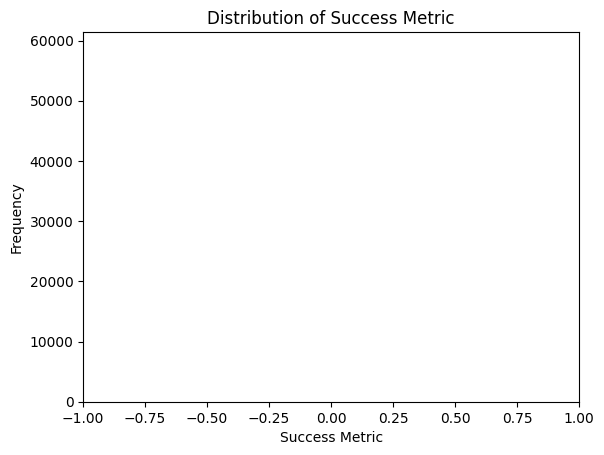

0.25    0.0
0.50    0.0
0.75    0.0
Name: success, dtype: float64


In [ ]:
from matplotlib import pyplot as plt

# histogram of success
plt.hist(success_df_final['success'], bins=1000)
# axis from -1 to 1:
plt.xlim(-1, 1)
plt.xlabel('Success Metric')
plt.ylabel('Frequency')
plt.title('Distribution of Success Metric')
plt.show()

# quantiles of success:
print(success_df_final['success'].quantile([0.25, 0.5, 0.75]))

0.25    0.0
0.50    0.0
0.75    0.0
Name: success, dtype: float64


Text(0.5, 1.0, 'Distribution of Success Metric')

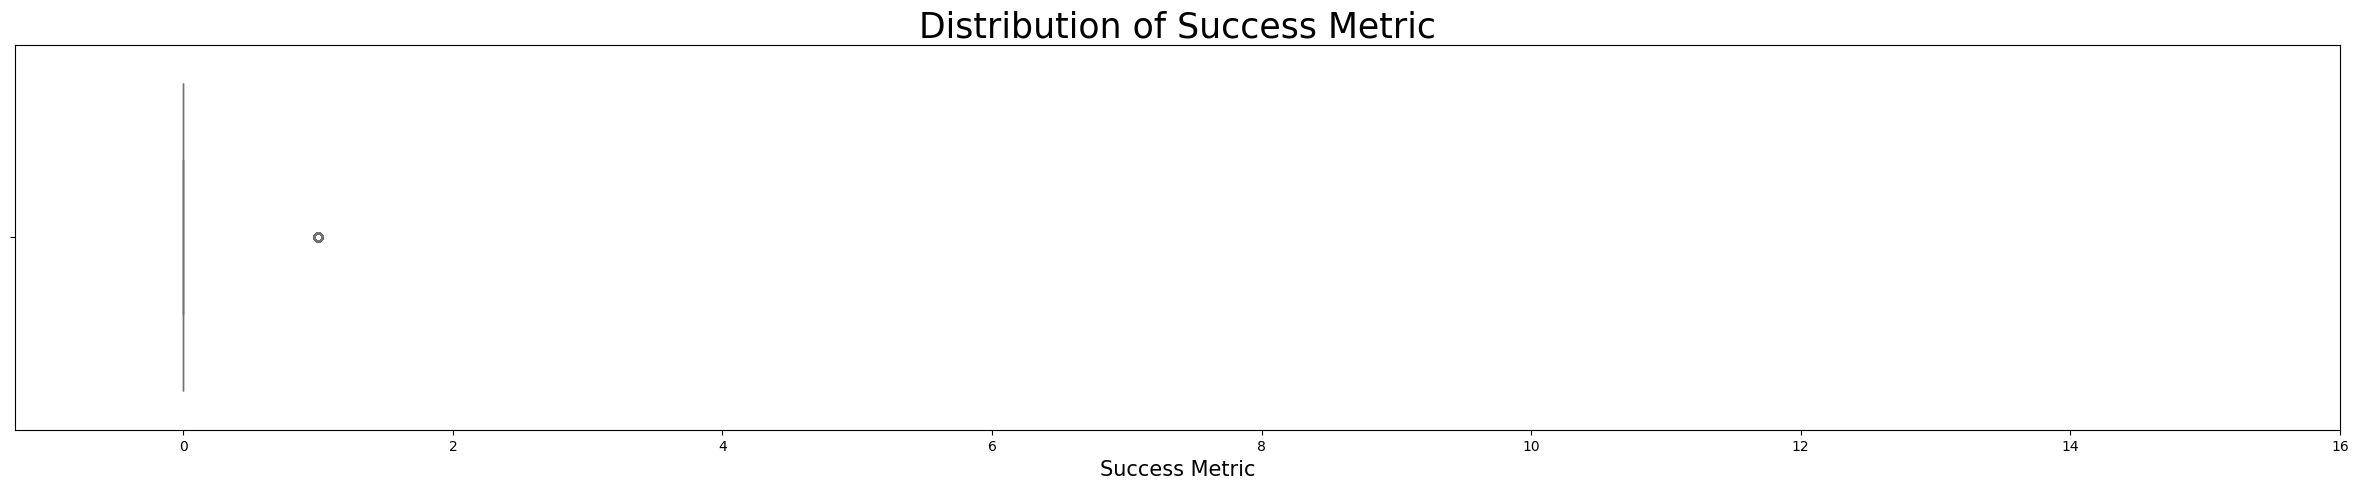

In [ ]:
fig, ax1 = plt.subplots(figsize = (30, 5))

sns.boxplot(success_df_final['success'], orient = 'h', color = 'khaki')

print(success_df_final['success'].quantile([0.25, 0.5, 0.75]))

plt.xlabel('Success Metric', fontsize = 15)
plt.xlim(-1.25, 16)
plt.title('Distribution of Success Metric', fontsize = 25)

In [ ]:
print('DataFrame Shape: {}'.format(success_df_final.shape))
print('DataFrame Info:')
print(success_df_final.info())

DataFrame Shape: (64675, 25)
DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 64675 entries, 0 to 51432
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   appid                 64369 non-null  float64
 1   name                  64359 non-null  object 
 2   genre                 64157 non-null  object 
 3   tags                  64369 non-null  object 
 4   positive              64369 non-null  float64
 5   negative              64369 non-null  float64
 6   recommendations       64369 non-null  float64
 7   days_released         64369 non-null  float64
 8   max_owners            64369 non-null  float64
 9   log_MaxOwnersPerDay   64369 non-null  float64
 10  log_initialprice      64369 non-null  float64
 11  log_median_2weeks     64369 non-null  float64
 12  log_median_forever    64369 non-null  float64
 13  log_ccu               64369 non-null  float64
 14  log_PosPerDay         64369 no

Unsure which graph we want to go with so I'm leaving both in and we can decide which we like better!

In [ ]:
# on appid joining success and success_binary to reg_df:
df_full = reg_df.merge(success_df_final[['appid', 'success']], on='appid', how='left') # Merging with reg_df

In [ ]:
print(df_full.shape)
df_full.sample(10)

(64425, 18)


,appid,name,genre,tags,initialprice,median_2weeks,median_forever,ccu,positive,negative,recommendations,days_released,max_owners,PosPerDay,NegPerDay,RecsPerDay,MaxOwnersPerDay,success
30140,1055150,Eva Reynes,"Adventure, Casual, Indie, RPG, Strategy","{'Adventure': 31, 'Indie': 31, 'Casual': 31, '...",9.99,0,0,0,9,5,0,1857.0,10000,0.004847,0.002693,0.000000,5.385030,0
7267,404850,DARTHY,"Casual, Indie","{'Indie': 43, 'Casual': 21, 'Platformer': 13, ...",0.99,0,183,0,37,7,0,3160.0,50000,0.011709,0.002215,0.000000,15.822785,0
42526,1752500,Badlands Racer,"Racing, Simulation","{'Racing': 72, 'Simulation': 65, 'Arcade': 43,...",1.99,0,0,0,13,14,0,1114.0,10000,0.011670,0.012567,0.000000,8.976661,0
63019,2940070,Parlor Board 3D,"Strategy, Free To Play","{'Strategy': 64, 'Board Game': 39, '3D Platfor...",0.00,0,0,0,4,0,0,155.0,10000,0.025806,0.000000,0.000000,64.516129,0
43075,1777120,STIX: Combat Devolved,"Action, Indie, Early Access","{'Action': 196, 'Top-Down Shooter': 171, 'PvP'...",0.00,0,0,0,11,1,0,977.0,10000,0.011259,0.001024,0.000000,10.235415,0
46089,1907620,Gamma Space,"Action, Adventure, Casual, Indie","{'Casual': 67, 'Adventure': 61, 'Action': 58, ...",3.99,0,0,0,1,1,0,956.0,10000,0.001046,0.001046,0.000000,10.460251,1
63002,2938470,WisdomGems,Indie,"{'Puzzle': 211, 'Grid-Based Movement': 205, 'S...",1.99,0,0,0,1,1,0,155.0,10000,0.006452,0.006452,0.000000,64.516129,0
43498,1794370,Philosopher's Stone and Minerva,"Action, Adventure, RPG","{'Tactical RPG': 159, '2D Platformer': 153, 'R...",7.99,0,0,0,1,0,0,1053.0,10000,0.000950,0.000000,0.000000,9.496676,0
1610,212630,Tom Clancy's Ghost Recon: Future Soldier,Action,"{'Action': 192, 'Stealth': 119, 'Third-Person ...",19.99,0,796,100,3659,1643,4627,4490.0,500000,0.814922,0.365924,1.030512,111.358575,0
9435,467330,Just a Cleric,"Action, Indie, RPG","{'RPG': 24, 'Action': 23, 'Indie': 23, 'Pixel ...",4.99,0,0,0,32,8,0,3067.0,10000,0.010434,0.002608,0.000000,3.260515,0


In [ ]:
#fill all nan with npne:
df_cleaned = df_full.fillna('none')

df_cleaned['genre'] = df_cleaned['genre'].fillna('none')

df_cleaned['genre'].isna().sum()

genre = df_cleaned['genre']

genre = genre.to_list()

type(genre)


list

In [ ]:
df_cleaned['tags'].fillna('none')

df_cleaned['tags'].isna().sum()

df_cleaned['tags_cleaned'] = df_cleaned['tags'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x)

df_cleaned['tags_cleaned'] = df_cleaned['tags_cleaned'].apply(lambda x: list(x.keys()) if isinstance(x, dict) else x)

In [ ]:
tags = df_full['tags']
# converting from string to dict:
tags = tags.apply(lambda x: ast.literal_eval(x))
#converting from dict to dict keys:
tag_keys = tags.apply(lambda x: x if isinstance(x, dict) else {}).apply(lambda x: list(x.keys()))
tag_keys

,tags
0,"[Action, FPS, Multiplayer, Shooter, Classic, T..."
1,"[Action, FPS, Multiplayer, Classic, Hero Shoot..."
2,"[FPS, World War II, Multiplayer, Shooter, Acti..."
3,"[Action, FPS, Classic, Multiplayer, Shooter, F..."
4,"[FPS, Action, Classic, Sci-fi, Singleplayer, S..."
...,...
64420,"[Arcade, Atmospheric, Surreal, Retro, Psychede..."
64421,"[Adventure, Simulation, Action, Puzzle, Walkin..."
64422,"[Choose Your Own Adventure, 3D Platformer, Hid..."
64423,"[Adventure, Casual, Sports, Conversation, Sing..."


In [ ]:
all_tags = [tag for tag_list in tag_keys for tag in tag_list]
tag_counts = Counter(all_tags)
tag_counts

Counter({'Action': 29052,
         'FPS': 4131,
         'Multiplayer': 8147,
         'Shooter': 6769,
         'Classic': 1463,
         'Team-Based': 852,
         'First-Person': 8506,
         'Competitive': 957,
         'Tactical': 2969,
         "1990's": 2053,
         'e-sports': 523,
         'PvP': 3511,
         'Old School': 2998,
         'Military': 1445,
         'Strategy': 13920,
         'Survival': 4799,
         'Score Attack': 1955,
         '1980s': 1469,
         'Assassin': 265,
         'Nostalgia': 182,
         'Hero Shooter': 446,
         'Class-Based': 421,
         'Co-op': 4111,
         'Fast-Paced': 1602,
         'Retro': 6809,
         'Online Co-Op': 2324,
         'Violent': 3986,
         'Funny': 7099,
         'Mod': 74,
         'Remake': 389,
         'World War II': 592,
         'War': 1903,
         'Historical': 1837,
         'Singleplayer': 35015,
         'Difficult': 5199,
         'World War I': 143,
         'Arena Shooter': 1189,


In [ ]:
import plotly.express as px

# Convert the tag counts to a DataFrame and select the top 100
tag_counts_df = pd.DataFrame.from_dict(tag_counts, orient='index', columns=['count']).sort_values('count', ascending=False).head(100)

# Create the bar chart
fig = px.bar(tag_counts_df, x=tag_counts_df.index, y='count', orientation='v', color_discrete_sequence=['hotpink'])
fig.update_layout(title='Top 100 Game Tags', xaxis_title='Tag', yaxis_title='Count')
fig.show()

In [ ]:

# Convert the tag counts to a DataFrame, sort, and select the top 25
tag_counts_df = pd.DataFrame.from_dict(tag_counts, orient='index', columns=['count']).sort_values('count', ascending=False).head(25)
tag_counts_df = tag_counts_df.iloc[::-1]

# Create the bar chart
fig = px.bar(tag_counts_df, x='count', y=tag_counts_df.index, orientation='h', color_discrete_sequence=['hotpink'])
fig.update_layout(title='Top 25 Game Tags', xaxis_title='Count', yaxis_title='Tag')
fig.show()

In [ ]:
for i in tag_keys:
  if len(i)>1:
    genre.append(i)

len(genre)

128157

In [ ]:
for i in genre:
  types = []
  types.append(type(i))

  unique = []
  if type(i) not in unique and len(i)>1:
    unique.append(type(i))

unique

[list]

In [ ]:
print(genre[5:6])

['Action']


In [ ]:
import pandas as pd

# Sample genre list provided directly as an example
# genre = [...] # Make sure 'genre' contains your full data when using this script

# Convert the genre list to a pandas DataFrame
genre_df = pd.DataFrame(genre, columns=['genres'])

# Function to handle different formats and clean genres
def process_genres(entry):
    # Case 1: If the entry is a single genre string, put it into a list if its length is greater than 1
    if isinstance(entry, str):
        return [entry] if len(entry.strip()) > 1 else []

    # Case 2: If the entry is already a list, filter out single-character genres
    if isinstance(entry, list):
        return [g for g in entry if isinstance(g, str) and len(g.strip()) > 1]

    # Unexpected case: return an empty list
    return []

# Apply the processing function to clean up the genres
genre_df['genres'] = genre_df['genres'].apply(process_genres)

# Remove rows where the 'genres' column is now empty
genre_df = genre_df[genre_df['genres'].map(len) > 0]


In [ ]:
genre_df.sample(10)

,genres
5940,"[Action, Adventure, Indie]"
100757,"[Adventure, RPG, Indie, Casual, Dating Sim]"
7267,"[Casual, Indie]"
52127,"[Action, Adventure, Indie, Early Access]"
16937,[Casual]
49806,"[Action, Adventure, Casual, Indie, Racing, RPG..."
25312,[Casual]
35395,"[Adventure, Indie]"
75788,"[Tactical RPG, Turn-Based Tactics, Party-Based..."
39575,"[Action, Indie, RPG, Simulation]"


In [ ]:
tag_count_list = list(tag_counts)
tag_count_list
len(tag_count_list)

450

In [ ]:
cleaned_genre = [[tag for tag in entry if len(tag) > 1] for entry in genre if isinstance(entry, list)]

# Ensure no empty lists are passed to Word2Vec
cleaned_genre = [entry for entry in cleaned_genre if entry]

In [ ]:
from gensim.models import Word2Vec
import gensim
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk
nltk.download('punkt')
import warnings

model1 = Word2Vec(sentences = cleaned_genre, min_count = 100)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
word_vectors = [model1.wv[tag] for tag in model1.wv.index_to_key]

In [ ]:
total_vocab_length = len(model1.wv.index_to_key)
print(total_vocab_length)

386


In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster,dendrogram
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Initial clustering using hierarchical clustering
initial_linked = linkage(word_vectors, method='ward')
cutoff_distance = 15  # Adjust this based on data
clusters = fcluster(initial_linked, t=cutoff_distance, criterion='distance')

# Step 1: Initial Clustering
linked = linkage(word_vectors, method='ward')

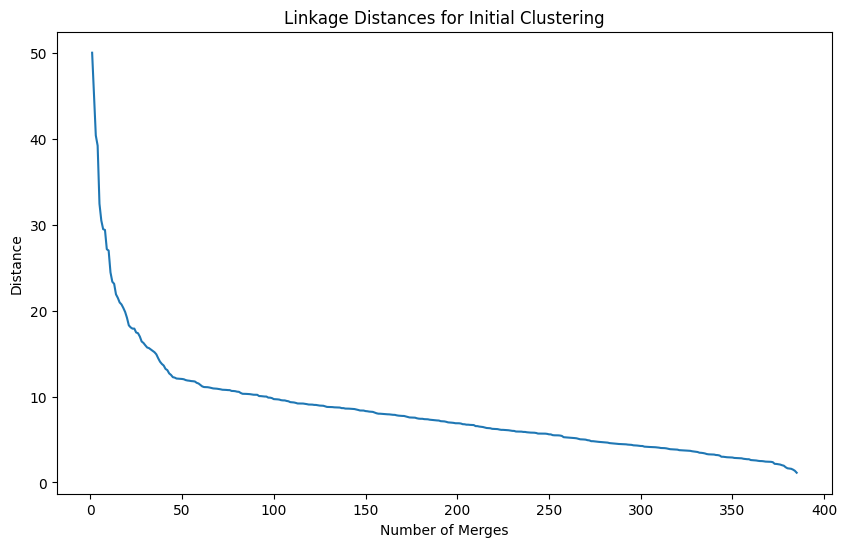

In [ ]:
from scipy.cluster.hierarchy import fcluster
import matplotlib.pyplot as plt

# Step 2: Visualize linkage distances (Elbow Method) for the original clustering
distances = linked[:, 2]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(distances) + 1), sorted(distances, reverse=True))
plt.title('Linkage Distances for Initial Clustering')
plt.xlabel('Number of Merges')
plt.ylabel('Distance')
plt.show()

In [ ]:
# Step 3: Initial clustering based on a cutoff distance determined by the elbow method
cutoff_distance = 15  # Adjust based on the elbow graph
clusters = fcluster(linked, t=cutoff_distance, criterion='distance')

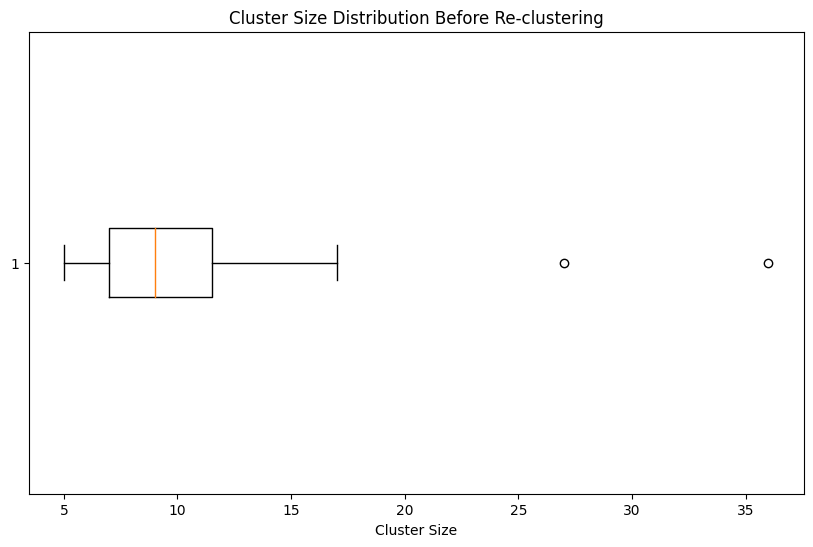

In [ ]:
# Step 4: Visualize original cluster sizes with a box-and-whisker plot
cluster_sizes = [np.sum(clusters == i) for i in np.unique(clusters)]

plt.figure(figsize=(10, 6))
plt.boxplot(cluster_sizes, vert=False)
plt.title('Cluster Size Distribution Before Re-clustering')
plt.xlabel('Cluster Size')
plt.show()

In [ ]:
# Step 5: Identify clusters that are too small or too large for re-clustering
min_cluster_size = 2
max_cluster_size = 15  # Adjust as needed

# Gather elements for re-clustering based on size
clusters_to_recluster = [i for i in np.unique(clusters) if cluster_sizes[i - 1] < min_cluster_size or cluster_sizes[i - 1] > max_cluster_size]

word_vectors = np.array(word_vectors)

indices_to_recluster = np.where(np.isin(clusters, clusters_to_recluster))[0]
# Step 6: Extract data points for re-clustering
data_for_reclustering = word_vectors[indices_to_recluster]
word_vectors = word_vectors.tolist()


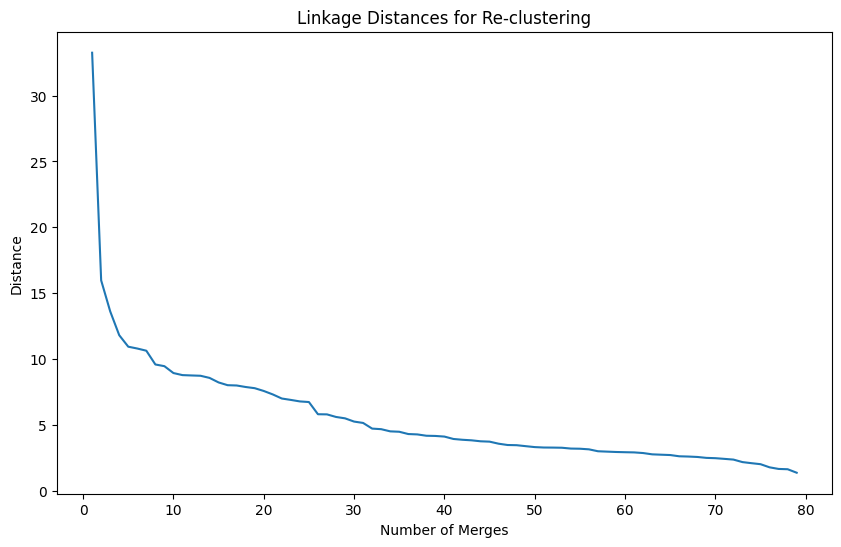

In [ ]:
# Step 7: Elbow Method for re-clustering the extracted clusters
linked_recluster = linkage(data_for_reclustering, method='ward')
distances_recluster = linked_recluster[:, 2]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(distances_recluster) + 1), sorted(distances_recluster, reverse=True))
plt.title('Linkage Distances for Re-clustering')
plt.xlabel('Number of Merges')
plt.ylabel('Distance')
plt.show()

In [ ]:
# Step 8: Determine cutoff for re-clustering using the new elbow graph
recluster_cutoff_distance = 8  # Adjust this based on the second elbow graph
new_clusters = fcluster(linked_recluster, t=recluster_cutoff_distance, criterion='distance')

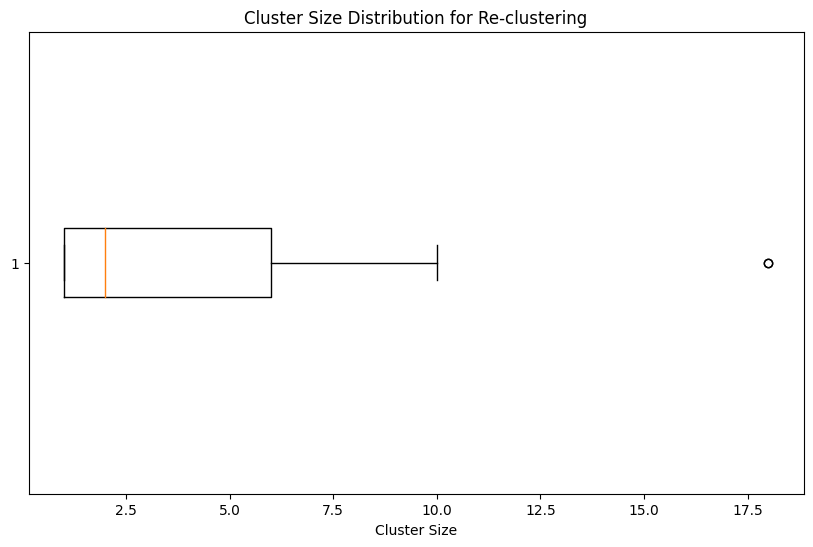

In [ ]:
# Step 9: Visualize reclustered cluster sizes with a box-and-whisker plot
cluster_sizes = [np.sum(new_clusters == i) for i in np.unique(new_clusters)]

plt.figure(figsize=(10, 6))
plt.boxplot(cluster_sizes, vert=False)
plt.title('Cluster Size Distribution for Re-clustering')
plt.xlabel('Cluster Size')
plt.show()


In [ ]:
# Step 10: Combine the new clusters with the original clusters
final_clusters = np.copy(clusters)
final_clusters[np.isin(clusters, clusters_to_recluster)] = new_clusters + clusters.max()  # Avoid overlap in cluster labels

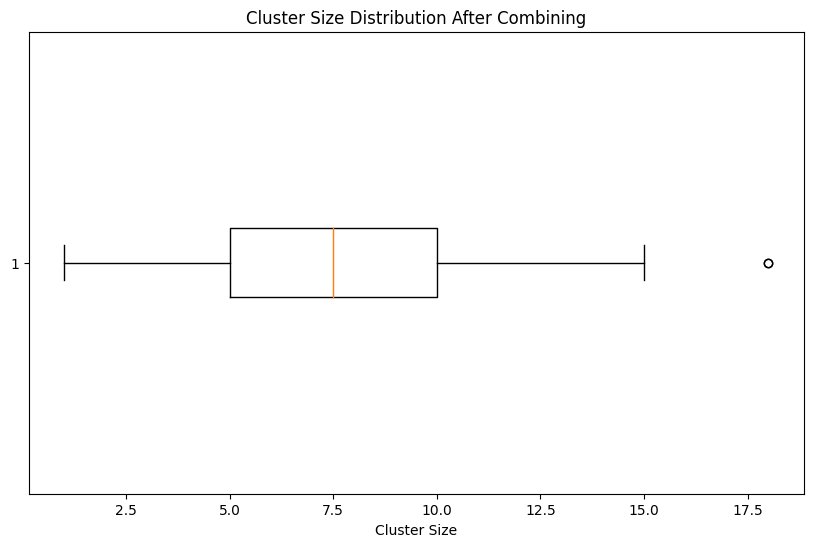

In [ ]:
# Step 11: Visualize final cluster sizes with a box-and-whisker plot
final_cluster_sizes = [np.sum(final_clusters == i) for i in np.unique(final_clusters)]

plt.figure(figsize=(10, 6))
plt.boxplot(final_cluster_sizes, vert=False)
plt.title('Cluster Size Distribution After Combining')
plt.xlabel('Cluster Size')
plt.show()

In [ ]:
# Load the clusters_renamed.csv file
clusters_df = pd.read_csv('/content/drive/MyDrive/Dat490/Data/clusters_renamed.csv')
print(clusters_df.columns)

# remove nans in content:
clusters_df = clusters_df.dropna(subset=['content'])
print(clusters_df.head())

# Extract words from the 'content' column and convert to lowercase
csv_words = set()
for words in clusters_df['content']:
    for word in words.split(','):
        csv_words.add(word.strip().lower())

# Extract words from the 'content' column of the DataFrame and convert to lowercase
df_words = set()
for words in clusters_df['content']:
    for word in words.split(','):
        df_words.add(word.strip().lower())

# Find words in the CSV that are not in the final clusters
words_not_in_clusters = csv_words - df_words

# Output the words not in the final clusters
print(f"Words in CSV not found in the final clusters: {words_not_in_clusters}")

Index(['cluster', 'content', 'rename cluster'], dtype='object')
   cluster                                            content  \
0     50.0  Modern, Crime, Alternate History, Noir, Americ...   
1      5.0  Arcade, Difficult, Controller,  Score Attack, ...   
2     23.0  Turn-Based Strategy, Card Game, Deckbuilding, ...   
3     39.0  Narration, Conversation, Philosophical, FMV, D...   
4      2.0  Family Friendly, Relaxing, Nature, Cats, Cozy,...   

      rename cluster  
0  Alternate Present  
1      Arcade-Style   
2      card_strategy  
3     conversational  
4               Cozy  
Words in CSV not found in the final clusters: set()


In [ ]:
type(df_full['tags'])

pandas.core.series.Series

In [ ]:
# Step 1: Fill NaN values in 'tags' and 'genre' columns with an empty string
df_full['tags'].fillna('', inplace=True)
df_full['genre'].fillna('', inplace=True)

# Convert cluster content to lowercase and store in a dictionary for quick lookup
cluster_dict = {}
all_cluster_words = set()  # To keep track of all words in clusters for filtering later
for idx, row in clusters_df.iterrows():
    cluster_name = row['rename cluster'].lower()  # Use the 'rename cluster' column
    cluster_content = set(word.strip().lower() for word in row['content'].split(','))  # Use the 'content' column
    cluster_dict[cluster_name] = cluster_content
    all_cluster_words.update(cluster_content)

# Function to parse the 'tags' column
def parse_tags(tag_str):
    if isinstance(tag_str, list):  # If it's a list, return lowercase tags
        return [tag.lower() for tag in tag_str]

    if isinstance(tag_str, str):  # Check if it's a string representation of a dictionary or list
        try:
            tag_dict = ast.literal_eval(tag_str)
            if isinstance(tag_dict, dict):  # If it's a dict, extract keys
                return [tag.lower() for tag in tag_dict.keys()]
            elif isinstance(tag_dict, list):  # If it's a list, return lowercase tags
                return [tag.lower() for tag in tag_dict]
        except (ValueError, SyntaxError):
            return []  # Return an empty list if parsing fails

    return []  # Return an empty list for unexpected formats

# Create a new column for processed tags
df_full['tag_processed'] = df_full['tags'].apply(parse_tags)

# Function to determine the clusters based on genre and tags
def assign_clusters(genre, tags):
    genre_lower = genre.lower()
    matching_clusters = set()

    for cluster_name, cluster_content in cluster_dict.items():
        if genre_lower in cluster_content or any(tag in cluster_content for tag in tags):
            matching_clusters.add(cluster_name)

    return list(matching_clusters)

# Apply the cluster assignment
df_full['game_cluster_features'] = df_full.apply(
    lambda x: assign_clusters(x['genre'], x['tag_processed']), axis=1
)

# Function to filter tags that are not part of any cluster
def filter_non_cluster_tags(tags):
    return [tag for tag in tags if tag not in all_cluster_words]

# Apply the filtering
df_full['non_cluster_tags'] = df_full['tag_processed'].apply(filter_non_cluster_tags)

# Combine game_cluster_features with the non-cluster tags
df_full['combined_features'] = df_full.apply(
    lambda x: x['game_cluster_features'] + x['non_cluster_tags'], axis=1
)

# Optional: Drop intermediate columns if not needed
df_full.drop(['tag_processed', 'non_cluster_tags'], axis=1, inplace=True)

# Output the DataFrame to check the results
print(df_full[['genre', 'tags', 'game_cluster_features', 'combined_features']])

<ipython-input-99-d5fed64dd60b>:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



<ipython-input-99-d5fed64dd60b>:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[

                                      genre  \
0                                    Action   
1                                    Action   
2                                    Action   
3                                    Action   
4                                    Action   
...                                     ...   
64420                                Casual   
64421  Action, Adventure, Indie, Simulation   
64422                      Adventure, Indie   
64423      Adventure, Casual, Indie, Sports   
64424  Adventure, Casual, Indie, Simulation   

                                                    tags  \
0      {'Action': 5477, 'FPS': 4902, 'Multiplayer': 3...   
1      {'Action': 764, 'FPS': 327, 'Multiplayer': 277...   
2      {'FPS': 799, 'World War II': 270, 'Multiplayer...   
3      {'Action': 635, 'FPS': 151, 'Classic': 115, 'M...   
4      {'FPS': 920, 'Action': 354, 'Classic': 286, 'S...   
...                                                  ...   
64420  {'Arcade

In [ ]:
cols = [col for col in df_full.columns if col != 'success'] + ['success']
df_full = df_full[cols]

In [ ]:
# drop game_cluster_features
df_full = df_full.drop(columns = ['game_cluster_features'])
df_full.sample(10)

,appid,name,genre,tags,initialprice,median_2weeks,median_forever,ccu,positive,negative,recommendations,days_released,max_owners,PosPerDay,NegPerDay,RecsPerDay,MaxOwnersPerDay,combined_features,success
49557,2088170,Medal of Guardians,"Action, Casual, Indie, RPG","{'Hero Shooter': 252, 'Bullet Hell': 246, 'Top...",3.99,0,0,23,11,5,0,693.0,100000,0.015873,0.007215,0.000000,144.300144,"[roguelike, simple_graphics, fighter, shooter,...",0
16620,678310,Pinball Deluxe: Reloaded,"Casual, Indie, Simulation","{'Indie': 31, 'Casual': 31, 'Simulation': 31, ...",7.99,0,0,6,163,7,163,2562.0,10000,0.063622,0.002732,0.063622,3.903201,"[management simulation, gamplay, exploration, ...",0
31677,1098540,Monsters sandbox,"Action, Indie, Massively Multiplayer","{'Arena Shooter': 198, 'Hack and Slash': 192, ...",0.99,0,0,0,13,5,0,1766.0,500000,0.007361,0.002831,0.000000,283.125708,"[openworld, survival, graphical, gamplay, figh...",0
22860,844750,Go-Kart Racing,"Indie, Racing, Simulation, Sports","{'Indie': 33, 'Racing': 33, 'Sports': 32, 'Sim...",0.99,0,0,0,80,68,115,2361.0,10000,0.033884,0.028801,0.048708,4.235493,"[management simulation, vehicle, gamplay]",0
29448,1035280,Stoppa!,Indie,"{'Indie': 21, 'Time Manipulation': 12, 'Platfo...",1.99,0,0,0,1,0,0,2037.0,10000,0.000491,0.000000,0.000000,4.909180,"[platformers, gamplay, structure]",0
6019,370660,Opaline,"Adventure, Casual, Indie, RPG","{'RPG': 32, 'Adventure': 29, 'Casual': 29, 'In...",6.99,0,0,0,50,19,0,2716.0,50000,0.018409,0.006996,0.000000,18.409426,"[romance, gamplay, creative tools, turn-based ...",0
40535,1371630,Incremental Adventures,"Casual, Free To Play, Indie, RPG","{'Idler': 189, 'Automation': 174, 'Text-Based'...",0.00,0,3068,105,572,157,0,1522.0,200000,0.375821,0.103154,0.000000,131.406045,"[gamplay, card_strategy, interactive_fiction, ...",0
224,7620,Railroad Tycoon II Platinum,Strategy,"{'Strategy': 75, 'Management': 66, 'Trains': 5...",4.99,0,1155,136,1098,130,1183,6370.0,500000,0.172370,0.020408,0.185714,78.492936,"[historical, strategy, vehicle, structure, mus...",0
59721,2663600,溢爱~fragile love,"Adventure, Casual, Indie, RPG","{'LGBTQ+': 97, 'Visual Novel': 90, 'Dating Sim...",1.99,0,0,0,60,1,0,310.0,10000,0.193548,0.003226,0.000000,32.258065,"[conversational, educational, romance, gamplay...",0
61933,2834430,Pizzakai,"Action, Casual, Indie, Free To Play","{'Action': 64, '2D Platformer': 38, 'Comedy': ...",0.00,0,0,0,8,2,0,144.0,10000,0.055556,0.013889,0.000000,69.444444,"[gamplay, humor, shooter, exploration, structu...",0


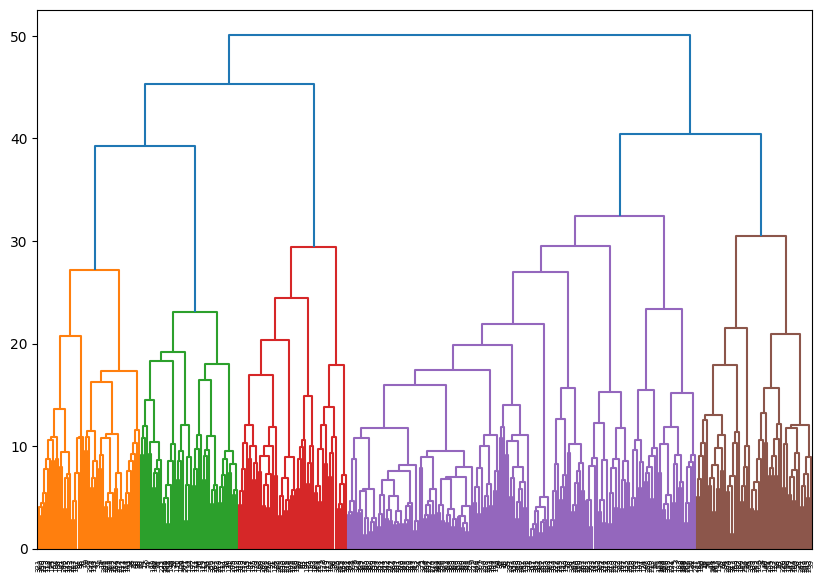

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.show()

In [ ]:
import scipy.cluster.hierarchy as sch
import numpy as np
import radialtree as rt

# Use the labels from your Word2Vec model, which is stored in `model1`
labels = model1.wv.index_to_key  # Extract the labels used in the Word2Vec clustering

Z2 = dendrogram(linked, labels=labels, no_plot=True)

# saving the plot:
plt.savefig('dendrogram.png')

# Plot the circular dendrogram using radialtree
rt.plot(Z2)


ModuleNotFoundError: No module named 'radialtree'

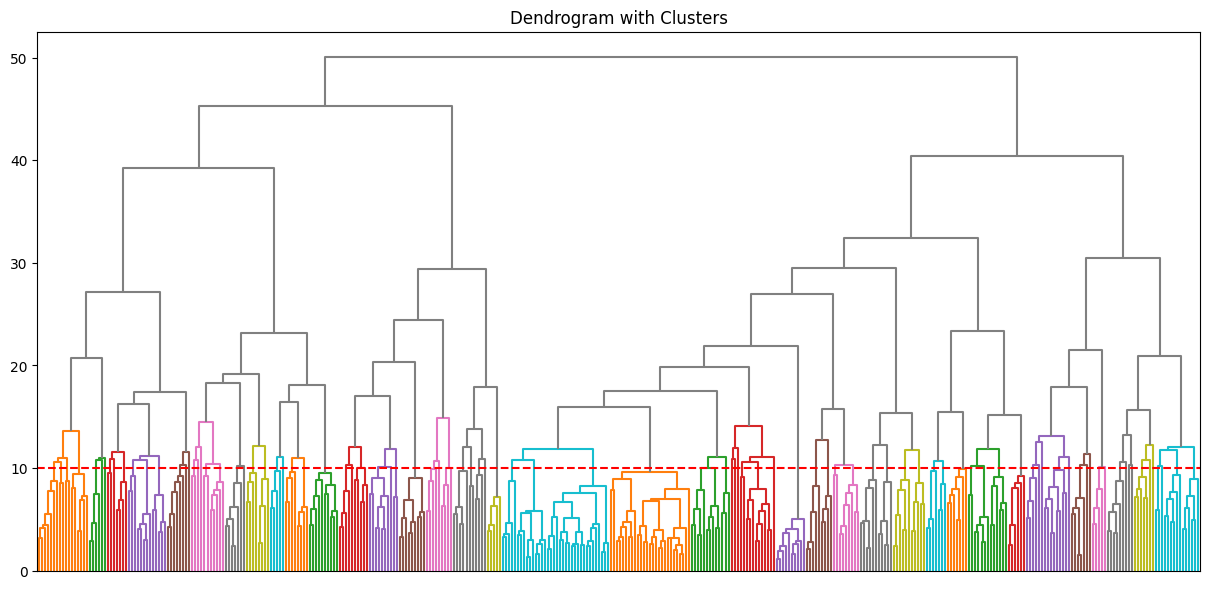

In [ ]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

# Redraw the dendrogram with the cutoff distance
plt.figure(figsize=(15, 7))
dendrogram(linked,
           color_threshold=cutoff_distance,  # Apply the cutoff
           above_threshold_color='grey',     # Color clusters above the threshold
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.axhline(y=10, color='r', linestyle='--')  # Horizontal line to mark the cutoff distance
plt.title('Dendrogram with Clusters')
#hide x-axis labels:
plt.xticks([])
plt.show()

Random Forest Model

*This can't be run until the success metric is figured out properly.*
*I figured that classifier would be the best bet for this since we're figuring out a binary target variable (success or not), if this changes that's perfectly fine!*

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfmod = RandomForestClassifier(n_estimators = 100, random_state = 254)

In [ ]:
# TODO For Tomorrow:
# Set up label encoder
# Make a copy of the full dataframe
# Encode the data so it is numerical
# Drop the name column as it is not important in the tree
# Run model

In [ ]:
# Setting up a label encoder to make genres and tags numerical
# Using a label encoder and not a one hot encoder due to number of genres and not having a specific rank (one is higher than the other)

from sklearn import preprocessing

label = preprocessing.LabelEncoder()

rfdf = df_full.copy()

In [ ]:
LDA_topics = pd.read_csv('/content/drive/MyDrive/Dat490/Data/top_topics_per_game.csv', index_col=False)
#comment game DB:
# Perform an inner merge to include only the games that have LDA topics
features_df = rfdf.merge(LDA_topics[['appid', 'lda_topics']], on='appid', how='inner')


In [ ]:
# game data all loading:
game_data = pd.read_csv('/content/drive/MyDrive/Dat490/Data/game_data_all.csv', index_col=False)

In [ ]:
game_data.info()

In [ ]:
game_data.head()

game_data['category'] = game_data.apply(lambda x: 'indie' if 'Indie' in str(x['genres']) or 'Indie' in str(x['tags']) else 'non-indie', axis=1)

In [ ]:
#add genre to features_df on appid:
features_df = features_df.merge(game_data[['steam_appid', 'genres']], left_on='appid', right_on='steam_appid', how='inner')
features_df.head()

In [ ]:
# fill all nans with empty strings instead of 0 for 'genres' and 'tags' columns
features_df['genres'] = features_df['genres'].fillna('').astype(str)
features_df['tags'] = features_df['tags'].fillna('').astype(str)

# fill remaining nans with 0 for other columns
features_df = features_df.fillna(0)

# Modify the lambda function to handle potential non-string values
features_df['category'] = features_df.apply(lambda x: 'indie' if 'Indie' in str(x['genres']) or 'Indie' in str(x['tags']) else 'non-indie', axis=1)

In [ ]:
features_df.head()
# Drop unnecessary columns
features_df = features_df.drop(['tags', 'genres', 'steam_appid', 'initialprice', 'median_2weeks', 'median_forever',
                                'ccu', 'positive', 'negative', 'recommendations', 'days_released', 'max_owners',
                                'PosPerDay', 'NegPerDay', 'RecsPerDay', 'MaxOwnersPerDay'], axis=1)

# Display the cleaned DataFrame
features_df.head()

In [ ]:
import re

def clean_features(features_str):
    """Cleans the 'all_features' column by removing double square brackets using regex.
    """
    # Convert features_str to string if it's not already
    features_str = str(features_str)  # This line ensures features_str is always a string

    # Remove double square brackets and their contents
    features_str = re.sub(r'\[\[.*?\]\]', '', features_str)
    # Remove remaining single square brackets
    features_str = re.sub(r'[\[\]]', '', features_str)
    # Split the string into a list of features
    features_list = [feature.strip() for feature in features_str.split(',') if feature.strip()]

    return features_list

# Apply the function to your column
features_df['all_features'] = features_df['all_features'].apply(clean_features)

In [ ]:
import ast
import re

def clean_features(features_str):
    """Cleans the 'all_features' column by first handling backslashes and
    extra quotes, then safely evaluating the string as a Python list.
    """
    # Convert to string and remove extra quotes and backslashes
    features_str = str(features_str)
    features_str = features_str.replace("\\", "")  # Remove backslashes
    features_str = re.sub(r"[\"']", '', features_str)  # Remove extra quotes

    # Remove brackets and split into a list
    features_str = re.sub(r"[\[\]]", "", features_str)
    features_list = [feature.strip() for feature in features_str.split(',') if feature.strip()]

    return features_list

# Apply the function to your column
features_df['all_features'] = features_df['all_features'].apply(clean_features)

In [ ]:
features_df.head(10)

In [ ]:
# saving feature df:
#features_df.to_csv('/content/drive/MyDrive/Dat490/Data/features_df.csv', index=False)
# loading:
features_df = pd.read_csv('/content/drive/MyDrive/Dat490/Data/features_df.csv')

In [ ]:


# Check the structure of features_df
print("\nFeatures DataFrame:")
print(features_df.head(10))

# Check the type of 'all_features' in both DataFrames
print("\nData type of 'all_features' in top_topics_per_game:")
print(type(top_topics_per_game['lda_topics'].iloc[0]))

print("\nData type of 'all_features' in features_df:")
print(type(features_df['all_features'].iloc[0]))

In [ ]:
#bar graph count of indie and nonindue games from all_features:
features_df['category'].value_counts().plot(kind='bar')

In [ ]:
rfdf = rfdf.drop(columns = ['name'])

rfdf.head()

In [ ]:

rfdf.sample(10)

In [ ]:
rfdf['genre'] = rfdf['genre'].fillna('none')

rfdf['tags'] = rfdf['tags'].fillna('none')

rfdf_copy = rfdf.copy()
rfdf_copy_features = rfdf.copy()

In [ ]:
short = []
movie = []
accounting = []
free = []
sexual = []
software = []
web = []
gore = []
audio = []
game = []
utilities = []
photo = []
education = []
design = []
early = []
none = []
sports = []
violent = []
nudity = []
massive = []
racing = []
simulation = []
casual = []
video = []
animation = []
rpg = []
indie = []
adventure = []
strat = []
action = []

def GenreEncoder(df, start, end, short, movie, accounting, free, sexual, software, web, gore, audio, game, utilities, photo,
                 eduction, design, early, none, sports, violent, nudity, massive, racing, simulation, casual, video, animation, rpg, indie,
                 adventure, strat, action):

  for i in range(start, end):

    if df.loc[i, 'genre'].find('Short') != -1:
      short.append(1)
    else:
      short.append(0)

    if df.loc[i, 'genre'].find('Movie') != -1:
      movie.append(1)
    else:
      movie.append(0)

    if df.loc[i, 'genre'].find('Accounting') != -1:
      accounting.append(1)
    else:
      accounting.append(0)

    if df.loc[i, 'genre'].find('Free') != -1:
      free.append(1)
    else:
      free.append(0)

    if df.loc[i, 'genre'].find('Sexual') != -1:
      sexual.append(1)
    else:
      sexual.append(0)

    if df.loc[i, 'genre'].find('Software') != -1:
      software.append(1)
    else:
      software.append(0)

    if df.loc[i, 'genre'].find('Web') != -1:
      web.append(1)
    else:
      web.append(0)

    if df.loc[i, 'genre'].find('Gore') != -1:
      gore.append(1)
    else:
      gore.append(0)

    if df.loc[i, 'genre'].find('Audio') != -1:
      audio.append(1)
    else:
      audio.append(0)

    if df.loc[i, 'genre'].find('Game') != -1:
      game.append(1)
    else:
      game.append(0)

    if df.loc[i, 'genre'].find('Utilities') != -1:
      utilities.append(1)
    else:
      utilities.append(0)

    if df.loc[i, 'genre'].find('Photo') != -1:
      photo.append(1)
    else:
      photo.append(0)

    if df.loc[i, 'genre'].find('Education') != -1:
      education.append(1)
    else:
      education.append(0)

    if df.loc[i, 'genre'].find('Design') != -1:
      design.append(1)
    else:
      design.append(0)

    if df.loc[i, 'genre'].find('Early') != -1:
      early.append(1)
    else:
      early.append(0)

    if df.loc[i, 'genre'].find('none') != -1:
      none.append(1)
    else:
      none.append(0)

    if df.loc[i, 'genre'].find('Sports') != -1:
      sports.append(1)
    else:
      sports.append(0)

    if df.loc[i, 'genre'].find('Violent') != -1:
      violent.append(1)
    else:
      violent.append(0)

    if df.loc[i, 'genre'].find('Nudity') != -1:
      nudity.append(1)
    else:
      nudity.append(0)

    if df.loc[i, 'genre'].find('Massively') != -1:
      massive.append(1)
    else:
      massive.append(0)

    if df.loc[i, 'genre'].find('Raciing') != -1:
      racing.append(1)
    else:
      racing.append(0)

    if df.loc[i, 'genre'].find('Simulation') != -1:
      simulation.append(1)
    else:
      simulation.append(0)

    if df.loc[i, 'genre'].find('Casual') != -1:
      casual.append(1)
    else:
      casual.append(0)

    if df.loc[i, 'genre'].find('Video') != -1:
      video.append(1)
    else:
      video.append(0)

    if df.loc[i, 'genre'].find('Animation') != -1:
      animation.append(1)
    else:
      animation.append(0)

    if df.loc[i, 'genre'].find('RPG') != -1:
      rpg.append(1)
    else:
      rpg.append(0)

    if df.loc[i, 'genre'].find('Indie') != -1:
      indie.append(1)
    else:
      indie.append(0)

    if df.loc[i, 'genre'].find('Adventure') != -1:
      adventure.append(1)
    else:
      adventure.append(0)

    if df.loc[i, 'genre'].find('Strategy') != -1:
      strat.append(1)
    else:
      strat.append(0)

    if df.loc[i, 'genre'].find('Action') != -1:
      action.append(1)
    else:
      action.append(0)

In [ ]:
GenreEncoder(rfdf,0, len(rfdf), short, movie, accounting, free, sexual, software, web, gore, audio, game, utilities, photo,
             education, design, early, none, sports, violent, nudity, massive, racing, simulation, casual, video, animation, rpg, indie,
             adventure, strat, action)

In [ ]:
unique_keywords = set()

# Iterate through the combined_features to get unique keywords
for features in df_full['combined_features']:
    if isinstance(features, list):  # Ensure it's a list
        unique_keywords.update(features)

# Convert to a sorted list
unique_keywords = sorted(unique_keywords)

# Step 2: Create the Genre Encoder function
def GenreEncoder2(df, combined_features_col):
    # Create a DataFrame for encoding
    encoded_df = pd.DataFrame(0, index=df.index, columns=unique_keywords)

    for i, features in enumerate(df[combined_features_col]):
        if isinstance(features, list):  # Ensure it's a list
            for feature in features:
                if feature in encoded_df.columns:
                    encoded_df.at[i, feature] = 1

    return encoded_df

# Step 3: Apply the Genre Encoder
# Step 3: Apply the Genre Encoder function
encoded_genres = GenreEncoder2(rfdf_copy_features, 'combined_features')
rfdf_encoded = pd.concat([rfdf_copy_features, encoded_genres], axis=1)

#clearing rfdf_copy from google colab( del)
del rfdf_copy


In [ ]:
rfdf_encoded['category'] = rfdf_encoded.apply(lambda x: 'indie' if 'Indie' in x['genre'] or 'Indie' in x['tags'] else 'non-indie', axis=1)
rfdf_encoded.head()

In [ ]:
GenreEncoder(df_full, start_index, end_index)

In [ ]:
rfdf = rfdf.drop(columns = 'genre')

In [ ]:
rfdf = rfdf.drop(columns = 'appid')

In [ ]:
#dropping all columns used for success, columns 32 - 43:
rfdf = rfdf.drop(columns = ['median_2weeks', 'median_forever', 'ccu', 'positive', 'negative', 'recommendations', 'days_released', 'max_owners', 'PosPerDay', 'NegPerDay'])
print(rfdf.info())

In [ ]:
genres = genre_df.loc[:, 'genre']
tags = tag_df.loc[:, 'tag']

#genres = labeler.fit_transform(genres)
#tags = labeler.fit_transform(tags)

In [ ]:
len(genres)

In [ ]:
genres = genres.to_list()


In [ ]:
for i in tags:
  for j in range(0, len(genres)):
    if genres[j].find(i) == -1:
      genres.append(i)

len(genres)

In [ ]:
tng = list(set(genres))

len(tng)

tng

In [ ]:
# I'm going to try and attempt to create a column for each tag

idx = 33

for i in tng:
  rfdf.insert(idx, i, 0)
  idx = idx + 1

In [ ]:
idx = 0

for i in range(0, len(rfdf)):
  for j in tags:
    if rfdf.loc[i, 'tags'].find(j) != -1:
      rfdf.loc[i, j] = 1

In [ ]:
rfdf.shape

In [ ]:
X = rfdf.iloc[:,0:483]
y = rfdf.loc[:, 'success']

X = X.drop(columns = ['tags','success'])

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 254)

In [ ]:
rfmod.fit(X_train, y_train)

y_preds = rfmod.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print('Accuracy Score for Training Data: {:.3f}'.format(rfmod.score(X_train, y_train)))
print('Accuracy Score for Test Data: {:.3f}'.format(accuracy_score(y_test, y_preds)))

In [ ]:
# Now we are gonna find the best metrics and range to use

params = {'max_depth':range(2,25)}

GSCV = GridSearchCV(RandomForestClassifier(random_state = 254), params, cv = 10)

GSCV.fit(X_train, y_train)

In [ ]:
# Will tell us what the best combination of criterion and depth are for the model

GSCV.best_estimator_

In [ ]:
best_rf = RandomForestClassifier(criterion = 'gini', max_depth = 21, random_state = 254)

In [ ]:
best_rf.fit(X_train, y_train)

y_preds = best_rf.predict(X_test)

print('Accuracy Score on Training Data: {:.3f}'.format(best_rf.score(X_train, y_train)))
print('Accuracy Score on Test Data: {:.3f}'.format(accuracy_score(y_test, y_preds)))

In [ ]:
tr_score = []
test_score = []
depth = []

for i in range(2, 25):
    rf_for = RandomForestClassifier(random_state = 254, criterion = 'gini', max_depth = i)
    rf_for.fit(X_train, y_train)

    y_pred = rf_for.predict(X_test)

    tr_score.append(rf_for.score(X_train, y_train))
    print('Training Accuracy for Depth {}: {:.3f}'.format(i, rf_for.score(X_train, y_train)))
    test_score.append(accuracy_score(y_test, y_pred))
    print('Test Accuracy for Depth {}: {:.3f}'.format(i, accuracy_score(y_test, y_pred)))
    depth.append(i)

In [ ]:
fig, ax1 = plt.subplots(figsize = (8,8))

ax1.plot(tr_score, '--o', color = 'steelblue')
ax1.plot(test_score, '-o', color = 'dodgerblue')
ax1.set_title('Training and Test Accuracy Scores for Depths')
ax1.set_xlabel('Depth')
ax1.set_ylabel('Accuracy Score')
ax1.legend(['Accuracy Scores for Training Data', 'Accuracy Scores for Test Data'])

In [ ]:
importance = pd.DataFrame(best_rf.feature_importances_, index = X_train.columns, columns = ['Importance'])

In [ ]:
importance = importance.sort_values('Importance', ascending = False)

importance

In [ ]:
importance_25 = importance.iloc[0:25, 0]

In [ ]:
fig, ax1 = plt.subplots(figsize = (8,8))

importance_25.plot.bar(ax = ax1, color = 'crimson', alpha = 0.5)
ax1.set_title('Feature Importance Chart', fontweight = 'bold')
ax1.set_xlabel('Features')
ax1.set_ylabel('Importance')

In [ ]:
# ROC Curve for random forest
# y_preds
from sklearn.metrics import roc_curve

brf_prob = best_rf.predict_proba(X_test)

fpr, tpr, threshold = roc_curve(y_test, brf_prob[:,1], pos_label = 1)
auc = np.trapz(tpr, fpr)

In [ ]:
brf_prob.shape

In [ ]:
fig, ax1 = plt.subplots(figsize = (8, 8))

ax1.step(fpr, tpr, color = 'mediumvioletred')
ax1.plot(fpr, fpr, '--' ,color = 'gray')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('AUC = {:.5f}'.format(auc))


Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()

logreg.fit(X_train, y_train)

In [ ]:
y_preds = logreg.predict(X_test)

print('Accuracy Score on Training Data: {:.3f}'.format(logreg.score(X_train)))
print('Accuracy Score on Test Data: {:.3f}'.format())

Markov Clustering

In [ ]:
pip install markov_clustering[drawing]

In [ ]:
import markov_clustering as mc

In [ ]:
from sklearn.preprocessing import LabelEncoder

labeler = LabelEncoder()

In [ ]:
rfdf.shape

In [ ]:
from sklearn.cluster import KMeans

km_mod = KMeans(n_clusters = 200, random_state = 254, n_init = 20)
km = km_mod.fit(X)

In [ ]:
y = km_mod.fit_predict(X)

In [ ]:
y = pd.DataFrame(data = y, columns = ['Clusters'])

y.Clusters.unique()

In [ ]:
fig, ax1 = plt.subplots(figsize = (8,8))

ax1.scatter(X)

In [ ]:
rfdf_copy_features['category'] = rfdf_copy_features.apply(lambda x: 'indie' if 'Indie' in x['genre'] or 'Indie' in x['tags'] else 'non-indie', axis=1)

In [ ]:
import networkx as nx

genres = genres.reshape(5, 6)
tags = tags.reshape(450, 1)

result1 = mc.run_mcl(genres)

#result2 = mc.run_mcl(tags)
#clusters = mc.get_clusters(result)

#mc.draw_graph(A, clusters, node_size=50, with_labels=False, edge_color="silver")